In [2]:
# Cell 1: Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime
import requests
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from fredapi import Fred
from pytrends.request import TrendReq
import warnings
import time

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

# Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)

In [3]:
# Cell 2: Data Loading Function (Run this cell if you need to download new data)
import yfinance as yf

def download_stock_data(ticker, start_date, end_date, save_path=None):
    """
    Download stock data using yfinance library
    
    Parameters:
    -----------
    ticker : str
        Stock ticker symbol (e.g., 'AAPL')
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    save_path : str, optional
        Path to save the CSV file
        
    Returns:
    --------
    pandas.DataFrame
        Stock price data
    """
    print(f"Downloading {ticker} data from {start_date} to {end_date}...")
    data = yf.download(ticker, start=start_date, end=end_date)
    
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        data.to_csv(save_path)
        print(f"Data saved to {save_path}")
    
    return data

# Example usage (uncomment to run)
ticker = 'AAPL'  # Apple stock
start_date = '2010-01-01'
end_date = '2025-03-24'
stock_data = download_stock_data(ticker, start_date, end_date, save_path='data/stock_data.csv')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Data saved to data/stock_data.csv


[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (3828, 5)
Detected multi-level columns, flattening structure...
Cleaning data...
Missing values before cleaning:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Removing 7 volume outliers
Data shape after cleaning: (3821, 5)
DataFrame columns: ['Close', 'High', 'Low', 'Open', 'Volume']
DataFrame shape: (3821, 5)


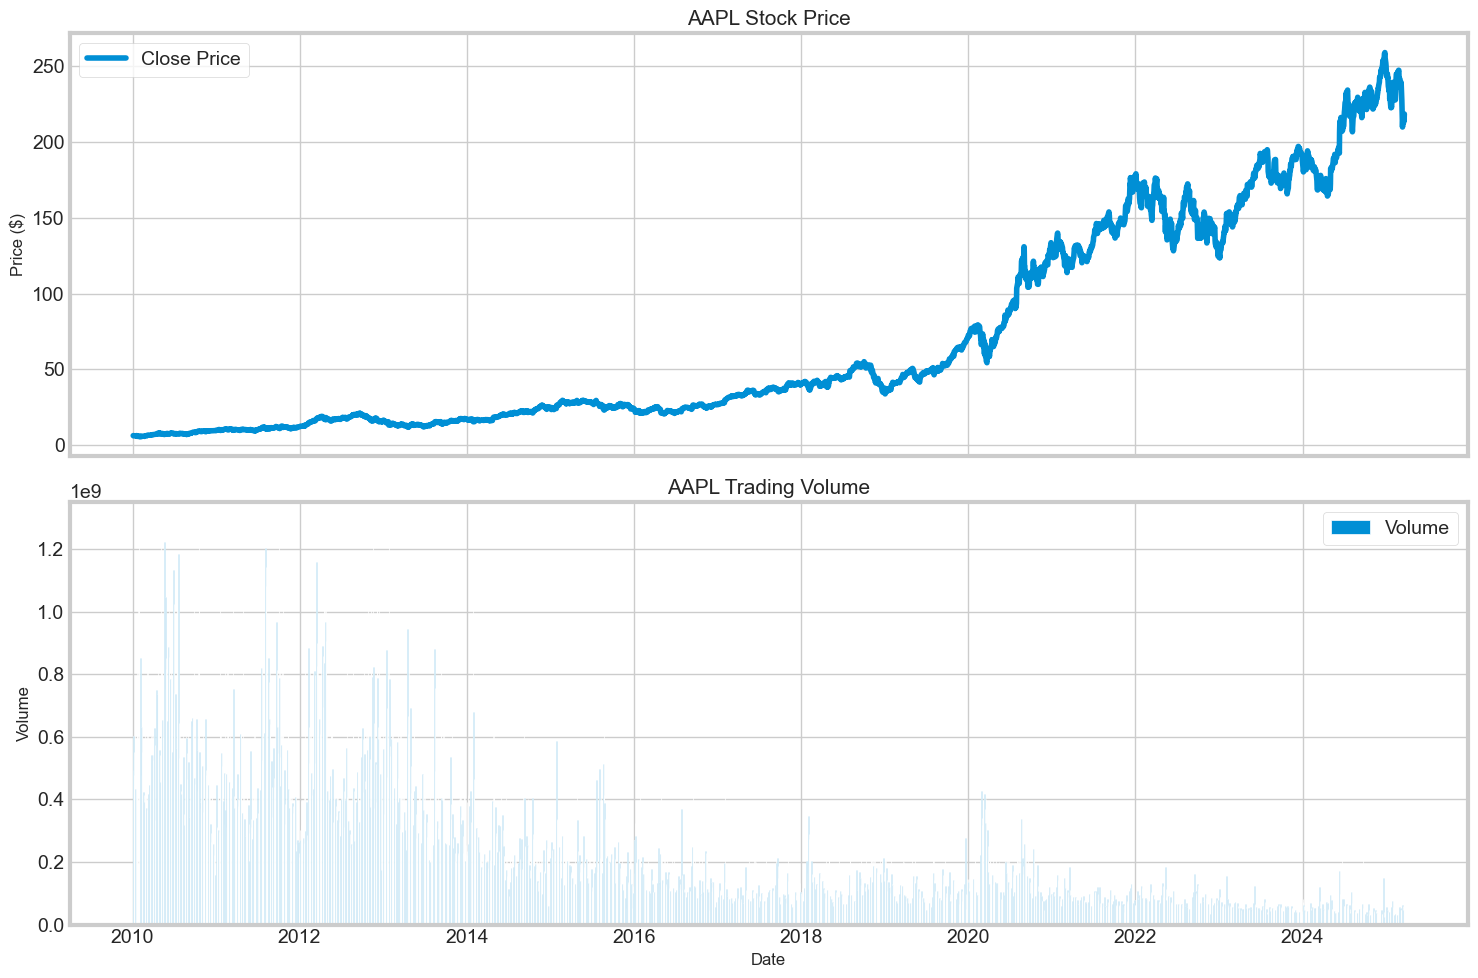

In [4]:
# Cell: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set styling for plots
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

# Cell: Load and Clean Stock Data
def load_stock_data(ticker, start_date, end_date):
    """Load stock data directly from yfinance"""
    print(f"Downloading {ticker} data from {start_date} to {end_date}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=True)
    print(f"Downloaded data shape: {df.shape}")
    
    # Check for multi-level columns and flatten if needed
    if isinstance(df.columns, pd.MultiIndex):
        print("Detected multi-level columns, flattening structure...")
        # If it's a multi-level columns dataframe, flatten it
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    return df

def clean_data(df):
    """Clean the data by handling missing values and outliers"""
    print("Cleaning data...")
    
    # Check for missing values
    missing_values = df.isnull().sum()
    print(f"Missing values before cleaning:\n{missing_values}")
    
    # Forward-fill small missing values
    df.fillna(method='ffill', inplace=True)
    
    # Check for multi-level columns and flatten if needed
    if isinstance(df.columns, pd.MultiIndex):
        print("Flattening multi-level columns...")
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    # Remove outliers
    if 'Volume' in df.columns:
        try:
            volume_mean = df['Volume'].mean()
            volume_std = df['Volume'].std()
            outlier_threshold = volume_mean + 5 * volume_std
            outliers = df[df['Volume'] > outlier_threshold]
            if not outliers.empty:
                print(f"Removing {len(outliers)} volume outliers")
                df = df[df['Volume'] <= outlier_threshold]
        except Exception as e:
            print(f"Error processing Volume column: {e}")
            print("Skipping outlier removal")
    
    print(f"Data shape after cleaning: {df.shape}")
    return df

# Cell: Plot Stock Data
def plot_stock_data(df, ticker="Stock"):
    """Plot stock price and volume data"""
    # Check for multi-level columns and flatten if needed
    if isinstance(df.columns, pd.MultiIndex):
        print("Flattening multi-level columns before plotting...")
        df = df.copy()
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    # Ensure all required columns exist
    required_cols = ['Close', 'Volume']
    for col in required_cols:
        if col not in df.columns:
            print(f"Error: '{col}' column not found in data")
            return
    
    # Print column info for debugging
    print(f"DataFrame columns: {df.columns.tolist()}")
    print(f"DataFrame shape: {df.shape}")
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Plot stock price
    ax1.plot(df.index, df['Close'], label='Close Price')
    ax1.set_title(f'{ticker} Stock Price', fontsize=15)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.grid(True)
    ax1.legend()
    
    # Plot volume
    ax2.bar(df.index, df['Volume'], label='Volume')
    ax2.set_title(f'{ticker} Trading Volume', fontsize=15)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Volume', fontsize=12)
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage

# Load and clean data
ticker = 'AAPL'
# start_date = '2016-01-01'
# end_date = '2025-03-24'
df = load_stock_data(ticker, start_date, end_date)
df_cleaned = clean_data(df)

# Plot the cleaned data
plot_stock_data(df_cleaned, ticker=ticker)


In [5]:
# Cell 3: Fetch and Process News Sentiment Data
def fetch_news_sentiment(ticker, days_back=180, api_key=None):
    """
    Fetch news headlines and calculate sentiment scores
    """
    if api_key is None:
        print("No API key provided. Please provide a valid NewsAPI key.")
        return pd.DataFrame(columns=['date', 'num_headlines', 'avg_sentiment'])
    
    # Download NLTK resources if needed
    try:
        nltk.data.find('vader_lexicon')
    except LookupError:
        nltk.download('vader_lexicon')
    
    # Initialize sentiment analyzer
    sia = SentimentIntensityAnalyzer()
    
    # Define date range
    end_date = datetime.date.today()
    start_date = end_date - datetime.timedelta(days=days_back)
    
    daily_sentiments = []
    
    current_date = start_date
    while current_date <= end_date:
        date_str = current_date.strftime("%Y-%m-%d")
        url = f"https://newsapi.org/v2/everything?q={ticker}&from={date_str}&to={date_str}&sortBy=popularity&apiKey={api_key}"
        
        try:
            response = requests.get(url)
            if response.status_code == 200:
                news_data = response.json()
                headlines = [article['title'] for article in news_data.get('articles', [])]
                
                if headlines:
                    sentiments = [sia.polarity_scores(headline)['compound'] for headline in headlines]
                    avg_sentiment = np.mean(sentiments)
                    daily_sentiments.append({
                        'date': date_str, 
                        'num_headlines': len(headlines), 
                        'avg_sentiment': avg_sentiment
                    })
                    print(f"Date: {date_str} | Headlines: {len(headlines)} | Avg Sentiment: {avg_sentiment:.4f}")
                else:
                    print(f"Date: {date_str} | No headlines found.")
            else:
                print(f"Error fetching news for {date_str}: {response.status_code}")
        except Exception as e:
            print(f"Exception fetching news for {date_str}: {e}")
        
        current_date += datetime.timedelta(days=1)
    
    # Convert to DataFrame
    sentiment_df = pd.DataFrame(daily_sentiments)
    
    if not sentiment_df.empty:
        # Convert date column to datetime and set as index
        sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
        sentiment_df.set_index('date', inplace=True)
        
        # Save to CSV
        sentiment_df.to_csv("data/news_sentiment.csv")
        print(f"News sentiment data saved to data/news_sentiment.csv")
    else:
        print("No sentiment data was collected.")
    
    return sentiment_df

# Example usage - Replace "YOUR_API_KEY" with your actual NewsAPI key
news_api_key = "deadcfcbb3024ab7b35a624b89533805"
# Uncomment the line below to actually fetch news sentiment
news_sentiment_df = fetch_news_sentiment(ticker, days_back=30, api_key=news_api_key)

# For testing purposes, we'll create a sample sentiment DataFrame
# In production, replace this with the actual API call above
# sample_dates = pd.date_range(start=stock_df.index[0], end=stock_df.index[-1], freq='D')
# news_sentiment_df = pd.DataFrame({
#     'num_headlines': np.random.randint(0, 20, size=len(sample_dates)),
#     'avg_sentiment': np.random.uniform(-0.5, 0.5, size=len(sample_dates))
# }, index=sample_dates)

# Save sample data
# news_sentiment_df.to_csv("data/news_sentiment_sample.csv")
# print("\nSample News Sentiment Data (first 5 rows):")
# print(news_sentiment_df.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\johni\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Error fetching news for 2025-02-22: 426
Error fetching news for 2025-02-23: 426
Date: 2025-02-24 | Headlines: 34 | Avg Sentiment: 0.0950
Date: 2025-02-25 | Headlines: 31 | Avg Sentiment: 0.0553
Date: 2025-02-26 | Headlines: 30 | Avg Sentiment: 0.0995
Date: 2025-02-27 | Headlines: 20 | Avg Sentiment: 0.1047
Date: 2025-02-28 | Headlines: 19 | Avg Sentiment: 0.0574
Date: 2025-03-01 | Headlines: 21 | Avg Sentiment: 0.1526
Date: 2025-03-02 | Headlines: 16 | Avg Sentiment: 0.3268
Date: 2025-03-03 | Headlines: 22 | Avg Sentiment: 0.0249
Date: 2025-03-04 | Headlines: 26 | Avg Sentiment: 0.2763
Date: 2025-03-05 | Headlines: 27 | Avg Sentiment: 0.1120
Date: 2025-03-06 | Headlines: 24 | Avg Sentiment: 0.1371
Date: 2025-03-07 | Headlines: 19 | Avg Sentiment: 0.0361
Date: 2025-03-08 | Headlines: 6 | Avg Sentiment: -0.0181
Date: 2025-03-09 | Headlines: 19 | Avg Sentiment: 0.1879
Date: 2025-03-10 | Headlines: 22 | Avg Sentiment: 0.1498
Date: 2025-03-11 | Headlines: 34 | Avg Sentiment: 0.1115
Date: 20

In [6]:
# Cell 4: Fetch Macroeconomic Indicators from FRED
def fetch_macro_indicators(start_date, end_date, api_key=None):
    """
    Fetch macroeconomic indicators from FRED
    """
    if api_key is None:
        print("No API key provided. Please provide a valid FRED API key.")
        return pd.DataFrame(columns=['DGS10', 'CPI', 'GDP', 'UNRATE'])
    
    try:
        fred = Fred(api_key=api_key)
        
        print("Fetching 10-Year Treasury rates...")
        # Fetch daily interest rates (10-Year Treasury Constant Maturity Rate)
        dgs10 = fred.get_series('DGS10', start_date, end_date)
        df_dgs10 = pd.DataFrame(dgs10, columns=['DGS10'])
        df_dgs10.index = pd.to_datetime(df_dgs10.index)
        
        print("Fetching CPI data...")
        # Fetch monthly CPI data
        cpi = fred.get_series('CPIAUCSL', start_date, end_date)
        df_cpi = pd.DataFrame(cpi, columns=['CPI'])
        df_cpi.index = pd.to_datetime(df_cpi.index)
        # Resample CPI to daily frequency using forward fill
        df_cpi_daily = df_cpi.resample('D').ffill()
        
        print("Fetching GDP data...")
        # Fetch quarterly GDP data
        gdp = fred.get_series('GDP', start_date, end_date)
        df_gdp = pd.DataFrame(gdp, columns=['GDP'])
        df_gdp.index = pd.to_datetime(df_gdp.index)
        # Resample GDP to daily frequency using forward fill
        df_gdp_daily = df_gdp.resample('D').ffill()
        
        print("Fetching unemployment rate data...")
        # Fetch unemployment rate (monthly)
        unrate = fred.get_series('UNRATE', start_date, end_date)
        df_unrate = pd.DataFrame(unrate, columns=['UNRATE'])
        df_unrate.index = pd.to_datetime(df_unrate.index)
        # Resample to daily frequency
        df_unrate_daily = df_unrate.resample('D').ffill()
        
        # Merge all macro indicators into one DataFrame
        macro_df = pd.concat([df_dgs10, df_cpi_daily, df_gdp_daily, df_unrate_daily], axis=1)
        
        # Forward fill missing values and fill remaining NaNs with 0
        macro_df = macro_df.ffill().fillna(0)
        
        # Save to CSV
        macro_df.to_csv("data/macro_indicators.csv")
        print(f"Macro indicators data saved to data/macro_indicators.csv")
        
        return macro_df
    
    except Exception as e:
        print(f"Error fetching macro indicators: {e}")
        # Create empty DataFrame with expected columns
        return pd.DataFrame(columns=['DGS10', 'CPI', 'GDP', 'UNRATE'])

# Example usage - Replace "YOUR_API_KEY" with your actual FRED API key
fred_api_key = "7841d255497334b51d98c59632502130"
# Uncomment the line below to actually fetch macro data
macro_df = fetch_macro_indicators(start_date, end_date, api_key=fred_api_key)

# For testing purposes, we'll create a sample macro DataFrame
# In production, replace this with the actual API call above
print("Creating sample macroeconomic indicators data...")
# Ensure we use proper dates from the cleaned stock dataframe
# start_date = stock_df.index.min()
# end_date = stock_df.index.max()
# sample_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# macro_df = pd.DataFrame({
#     'DGS10': np.random.uniform(1.5, 4.0, size=len(sample_dates)),  # 10-Year Treasury Rate
#     'CPI': np.linspace(250, 300, len(sample_dates)),  # Consumer Price Index (upward trend)
#     'GDP': np.linspace(20000, 23000, len(sample_dates)),  # GDP (upward trend)
#     'UNRATE': np.clip(np.random.normal(4.0, 1.0, size=len(sample_dates)), 3.0, 15.0)  # Unemployment Rate
# }, index=sample_dates)

# Save sample data
macro_df.to_csv("data/macro_indicators_sample.csv")
print("\nSample Macro Indicators Data (first 5 rows):")
print(macro_df.head())

Fetching 10-Year Treasury rates...
Fetching CPI data...
Fetching GDP data...
Fetching unemployment rate data...
Macro indicators data saved to data/macro_indicators.csv
Creating sample macroeconomic indicators data...

Sample Macro Indicators Data (first 5 rows):
            DGS10      CPI       GDP  UNRATE
2010-01-01   0.00  217.488  14764.61     9.8
2010-01-02   0.00  217.488  14764.61     9.8
2010-01-03   0.00  217.488  14764.61     9.8
2010-01-04   3.85  217.488  14764.61     9.8
2010-01-05   3.77  217.488  14764.61     9.8


In [7]:
# Import the necessary library from pytrends
from pytrends.request import TrendReq

# Step 1: Set up a connection to Google Trends using pytrends.
# Think of it as opening a door to ask Google about search trends.
pytrends = TrendReq(hl='en-US', tz=360)

# Step 2: Define the search term and the time period.
# We'll search for "Apple" (the company) and use a timeframe that matches our stock data.
# For example, if our stock data is from 5 years ago until today,
# we build a string with those dates.
timeframe = "all"

# List of keywords to search for. We use a list even if it has one item.
kw_list = ["Apple"]

# Step 3: Build the payload.
# This tells Google Trends what we want to know.
pytrends.build_payload(kw_list, cat=0, timeframe=timeframe, geo='', gprop='')

# Step 4: Fetch the interest over time.
# Google Trends will return a DataFrame where each row is a date and the value is how popular "Apple" is.
# Wrap in try/except to handle rate limiting
try:
    pytrends.build_payload(kw_list, cat=0, timeframe=timeframe, geo='', gprop='')
    interest_over_time_df = pytrends.interest_over_time()
    if 'isPartial' in interest_over_time_df.columns:
        interest_over_time_df = interest_over_time_df.drop(columns=['isPartial'])
except TooManyRequestsError as e:
    print("Too many requests. Waiting for 60 seconds before retrying...")
    time.sleep(60)
    pytrends.build_payload(kw_list, cat=0, timeframe=timeframe, geo='', gprop='')
    interest_over_time_df = pytrends.interest_over_time()
    if 'isPartial' in interest_over_time_df.columns:
        interest_over_time_df = interest_over_time_df.drop(columns=['isPartial'])
# Print the first few rows so we can see what it looks like.
print("Google Trends Interest Over Time for 'Apple':")
print(interest_over_time_df.head())

# Optional: If the data is weekly and you want daily values,
# you could resample it (for example, using forward fill). Uncomment if needed.
# interest_over_time_daily = interest_over_time_df.resample('D').ffill()
# print("Resampled Daily Google Trends Data:")
# print(interest_over_time_daily.head())


Google Trends Interest Over Time for 'Apple':
            Apple
date             
2004-01-01     21
2004-02-01     19
2004-03-01     18
2004-04-01     18
2004-05-01     18


In [8]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import datetime
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

def fetch_gdelt_sentiment_apple():
    """
    Queries the GDELT v2 events dataset in BigQuery to retrieve daily average tone
    for rows that mention 'APPLE' in Actor1Name or Actor2Name over the last ~6 months.
    Returns a DataFrame with columns: ['gdelt_sentiment'] indexed by date.
    """
    # Initialize BigQuery client with your project ID (replace with your actual project ID)
    client = bigquery.Client(project="machinelearning111")
    
    # Updated query using SQLDATE instead of EventDate
    query = """
    WITH filtered AS (
      SELECT
        PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING)) AS event_date,
        AvgTone
      FROM
        `gdelt-bq.gdeltv2.events`
      WHERE
        PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING)) >= DATE_SUB(CURRENT_DATE(), INTERVAL 5 YEAR)
        AND (
          LOWER(Actor1Name) LIKE '%apple%'
          OR LOWER(Actor2Name) LIKE '%apple%'
        )
    )
    SELECT
      event_date AS date,
      AVG(AvgTone) AS daily_tone
    FROM filtered
    GROUP BY date
    ORDER BY date
    """
    
    job = client.query(query)
    results = job.result()
    rows = list(results)
    
    # Convert results to DataFrame
    data = []
    for row in rows:
        data.append({'date': row.date, 'daily_tone': row.daily_tone})
    
    df_gdelt = pd.DataFrame(data)
    if not df_gdelt.empty:
        df_gdelt.set_index('date', inplace=True)
        df_gdelt.rename(columns={'daily_tone': 'gdelt_sentiment'}, inplace=True)
    else:
        df_gdelt = pd.DataFrame(columns=['gdelt_sentiment'])
    
    return df_gdelt

# Fetch GDELT data
df_gdelt = fetch_gdelt_sentiment_apple()
print("\nGDELT DataFrame (Apple mentions) Head:")
print(df_gdelt.head(50))


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\johni\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



GDELT DataFrame (Apple mentions) Head:
            gdelt_sentiment
date                       
2020-03-25         2.675781
2020-03-26        -2.808404
2020-03-30        -0.271997
2020-03-31         0.271287
2020-04-01         2.077922
2020-04-02         0.371747
2020-04-03        -2.277578
2020-04-04        -3.808354
2020-04-05        -1.618341
2020-04-06        -1.628197
2020-04-07         0.441434
2020-04-08        -0.899467
2020-04-09        -1.977644
2020-04-10         0.727070
2020-04-11         0.529568
2020-04-12         0.000000
2020-04-13         0.133281
2020-04-14         2.343751
2020-04-15        -1.515280
2020-04-16        -0.474691
2020-04-17         1.425060
2020-04-18        -0.036230
2020-04-20         2.040816
2020-04-21        -0.591716
2020-04-22        -5.494505
2020-04-23        -0.984180
2020-04-24        -2.774149
2020-04-25        -1.781016
2020-04-27        -0.857351
2020-04-28         2.734375
2020-04-29        -0.715528
2020-04-30        -0.168556
2020-05-

In [9]:
# Cell 5: Merge All Data Sources
def merge_all_data_sources():
    """
    Merge all previously collected data sources into a single DataFrame
    """
    print("Merging all data sources...")
    
    # Load stock data with special handling for multi-level structure
    try:
        print("Loading stock data...")
        # First, check if the file has the multi-level structure by examining the first few rows
        with open("data/stock_data.csv", 'r') as f:
            first_lines = [next(f) for _ in range(5)]
        
        # If the first rows contain "Price", "Ticker", or "Date" as headers, assume multi-level structure
        if any('Price' in line or 'Ticker' in line or 'Date,nan' in line for line in first_lines):
            print("Detected multi-level structure, cleaning data...")
            # Skip header rows and set proper column names
            stock_df = pd.read_csv("data/stock_data.csv", skiprows=3, 
                                  names=["Date", "Close", "High", "Low", "Open", "Volume"])
            stock_df["Date"] = pd.to_datetime(stock_df["Date"])
            stock_df.set_index("Date", inplace=True)
        else:
            # Try standard loading first
            stock_df = pd.read_csv("data/stock_data.csv", index_col=0, parse_dates=True)
            
            # Additional check for multi-level columns after loading
            if isinstance(stock_df.columns, pd.MultiIndex):
                print("Detected multi-level columns, flattening structure...")
                stock_df.columns = [col[0] if isinstance(col, tuple) else col for col in stock_df.columns]
        
        print(f"Stock data shape: {stock_df.shape}")
        print(f"Stock data columns: {stock_df.columns.tolist()}")
        print(f"Stock data index type: {type(stock_df.index)}")
        print(f"Stock data date range: {stock_df.index.min()} to {stock_df.index.max()}")
    except Exception as e:
        print(f"Error loading stock data: {e}")
        # Fallback method for loading
        try:
            print("Attempting fallback method for loading stock data...")
            # Try load_stock_data function if it's defined in your namespace
            stock_df = load_stock_data(ticker="AAPL", start_date="2018-01-01", end_date="2023-01-01")
            stock_df = clean_data(stock_df)
            print(f"Loaded stock data using fallback method with shape: {stock_df.shape}")
        except Exception as e2:
            print(f"Fallback method also failed: {e2}")
            return None
    
    # Load news sentiment data if available
    try:
        print("Loading news sentiment data...")
        news_df = pd.read_csv("data/news_sentiment.csv", index_col=0, parse_dates=True)
        print(f"News sentiment data shape: {news_df.shape}")
    except Exception as e:
        print(f"News sentiment data not found or error: {e}")
        news_df = pd.DataFrame()
    
    # Load macro indicators data if available
    try:
        print("Loading macro indicators data...")
        # Try both filenames
        try:
            macro_df = pd.read_csv("data/macro_indicators.csv", index_col=0, parse_dates=True)
        except:
            macro_df = pd.read_csv("data/macro_indicators_sample.csv", index_col=0, parse_dates=True)
        print(f"Macro indicators data shape: {macro_df.shape}")
    except Exception as e:
        print(f"Macro indicators data not found or error: {e}")
        macro_df = pd.DataFrame()
    
    # Load Google Trends data if available
    try:
        print("Loading Google Trends data...")
        # Try loading the interest_over_time_df if it exists
        try:
            trends_df = interest_over_time_df.copy()
            # Ensure datetime index
            if not isinstance(trends_df.index, pd.DatetimeIndex):
                trends_df.index = pd.to_datetime(trends_df.index)
            print(f"Google Trends data loaded from variable with shape: {trends_df.shape}")
        except:
            # Otherwise try to load from CSV files
            try:
                trends_df = pd.read_csv("data/google_trends.csv", index_col=0, parse_dates=True)
            except:
                try:
                    trends_df = pd.read_csv("data/google_trends_sample.csv", index_col=0, parse_dates=True)
                except:
                    # Create empty DataFrame if no data is found
                    trends_df = pd.DataFrame()
            if not trends_df.empty:
                print(f"Google Trends data loaded from CSV with shape: {trends_df.shape}")
    except Exception as e:
        print(f"Google Trends data not found or error: {e}")
        trends_df = pd.DataFrame()
    
    # Load GDELT sentiment data if available
    try:
        print("Loading GDELT sentiment data...")
        try:
            # Try to use the df_gdelt variable if it exists
            gdelt_df = df_gdelt.copy()
            print(f"GDELT sentiment data loaded from variable with shape: {gdelt_df.shape}")
        except:
            # Otherwise check for CSV file
            try:
                gdelt_df = pd.read_csv("data/gdelt_sentiment.csv", index_col=0, parse_dates=True)
                print(f"GDELT sentiment data loaded from CSV with shape: {gdelt_df.shape}")
            except:
                gdelt_df = pd.DataFrame()
    except Exception as e:
        print(f"GDELT sentiment data not found or error: {e}")
        gdelt_df = pd.DataFrame()
    
    # Create date ranges for resampling if needed, with error checking
    try:
        date_min = stock_df.index.min()
        date_max = stock_df.index.max()
        print(f"Stock data date range: {date_min} to {date_max}")
        
        # Validate that the dates are actually datetime objects and not strings
        if not isinstance(date_min, pd.Timestamp) or not isinstance(date_max, pd.Timestamp):
            print(f"Warning: Index dates are not proper timestamps. Min: {type(date_min)}, Max: {type(date_max)}")
            # Try to handle the case where we have a string-like date value
            if hasattr(stock_df.index, 'dtype') and stock_df.index.dtype == 'object':
                # Convert string dates to datetime if needed
                stock_df.index = pd.to_datetime(stock_df.index, errors='coerce')
                # Drop rows with NaT in index which couldn't be converted
                stock_df = stock_df[~stock_df.index.isna()]
                date_min = stock_df.index.min()
                date_max = stock_df.index.max()
                print(f"Converted index to datetime. New date range: {date_min} to {date_max}")
    except Exception as e:
        print(f"Error determining date range: {e}")
        # Use a default date range if we can't determine it
        date_min = pd.Timestamp('2018-01-01')
        date_max = pd.Timestamp('2023-01-01')
        print(f"Using default date range: {date_min} to {date_max}")
    
    # Start with stock data
    enhanced_df = stock_df.copy()
    
    # Merge news sentiment data
    if not news_df.empty:
        print("Merging news sentiment data...")
        # First, check if dates align
        print(f"News data date range: {news_df.index.min()} to {news_df.index.max()}")
        enhanced_df = enhanced_df.join(news_df, how='left')
        
        # Fill missing values
        if 'num_headlines' in enhanced_df.columns:
            missing_count = enhanced_df['num_headlines'].isna().sum()
            enhanced_df['num_headlines'] = enhanced_df['num_headlines'].fillna(0)
            print(f"Filled {missing_count} missing values in num_headlines")
        if 'avg_sentiment' in enhanced_df.columns:
            missing_count = enhanced_df['avg_sentiment'].isna().sum()
            enhanced_df['avg_sentiment'] = enhanced_df['avg_sentiment'].fillna(0)
            print(f"Filled {missing_count} missing values in avg_sentiment")
    
    # Merge macro indicators data
    if not macro_df.empty:
        print("Merging macro indicators data...")
        # First, check if dates align
        print(f"Macro data date range: {macro_df.index.min()} to {macro_df.index.max()}")
        enhanced_df = enhanced_df.join(macro_df, how='left')
        
        # Fill missing values
        for col in macro_df.columns:
            if col in enhanced_df.columns:
                missing_count = enhanced_df[col].isna().sum()
                enhanced_df[col] = enhanced_df[col].ffill().fillna(0)
                print(f"Filled {missing_count} missing values in {col}")
    
    # Merge Google Trends data
    if not trends_df.empty:
        print("Merging Google Trends data...")
        # Prepare google trends data - resample if weekly data
        try:
            if trends_df.index.freq != 'D' and len(trends_df.index) > 0:
                print("Resampling Google Trends data to daily frequency...")
                # Safer approach to create a date range
                if isinstance(date_min, pd.Timestamp) and isinstance(date_max, pd.Timestamp):
                    # Create a date range to cover the stock data period
                    full_date_range = pd.date_range(start=date_min, end=date_max, freq='D')
                    # Reindex and forward fill
                    trends_df = trends_df.reindex(trends_df.index.union(full_date_range))
                    trends_df = trends_df.resample('D').ffill()
                else:
                    print("Cannot resample Google Trends data - date range is invalid")
            
            print(f"Google Trends data date range: {trends_df.index.min()} to {trends_df.index.max()}")
            enhanced_df = enhanced_df.join(trends_df, how='left')
            
            # Fill missing values
            for col in trends_df.columns:
                if col in enhanced_df.columns:
                    missing_count = enhanced_df[col].isna().sum()
                    enhanced_df[col] = enhanced_df[col].ffill().fillna(0)
                    print(f"Filled {missing_count} missing values in {col}")
        except Exception as e:
            print(f"Error merging Google Trends data: {e}")
    
    # Merge GDELT sentiment data
    if not gdelt_df.empty:
        print("Merging GDELT sentiment data...")
        print(f"GDELT data date range: {gdelt_df.index.min()} to {gdelt_df.index.max()}")
        enhanced_df = enhanced_df.join(gdelt_df, how='left')
        
        # Fill missing values
        if 'gdelt_sentiment' in enhanced_df.columns:
            missing_count = enhanced_df['gdelt_sentiment'].isna().sum()
            enhanced_df['gdelt_sentiment'] = enhanced_df['gdelt_sentiment'].ffill().fillna(0)
            print(f"Filled {missing_count} missing values in gdelt_sentiment")
    
    # Create a group column for time-series CV
    enhanced_df['group'] = pd.Series(enhanced_df.index.date, index=enhanced_df.index)
    
    # Save enhanced data
    enhanced_df.to_csv("data/merged_data.csv")
    print(f"Merged data saved to data/merged_data.csv with shape {enhanced_df.shape}")
    
    return enhanced_df

# Execute data merging
merged_df = merge_all_data_sources()

# Display merged data preview
if merged_df is not None:
    print("\nMerged Data Preview:")
    print(merged_df.head())
    
    # Show merged columns
    print("\nMerged Data Columns:")
    print(merged_df.columns.tolist())

Merging all data sources...
Loading stock data...
Detected multi-level structure, cleaning data...
Stock data shape: (3828, 5)
Stock data columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Stock data index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Stock data date range: 2010-01-04 00:00:00 to 2025-03-21 00:00:00
Loading news sentiment data...
News sentiment data shape: (28, 2)
Loading macro indicators data...
Macro indicators data shape: (5545, 4)
Loading Google Trends data...
Google Trends data loaded from variable with shape: (255, 1)
Loading GDELT sentiment data...
GDELT sentiment data loaded from variable with shape: (1250, 1)
Stock data date range: 2010-01-04 00:00:00 to 2025-03-21 00:00:00
Merging news sentiment data...
News data date range: 2025-02-24 00:00:00 to 2025-03-23 00:00:00
Filled 3808 missing values in num_headlines
Filled 3808 missing values in avg_sentiment
Merging macro indicators data...
Macro data date range: 2010-01-01 00:00:00 to 2025-03-20 00

In [61]:
# Cell 6: Calculate Technical Indicators
def calculate_technical_indicators(df=None, use_merged=True):
    """
    Calculate various technical indicators for the stock data
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with stock data. If None, will try to load from merged_data.csv
    use_merged : bool
        Whether to use the merged data file or the original stock data file
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with added technical indicators
    """
    print("Calculating technical indicators...")
    
    # Load data if not provided
    if df is None:
        try:
            if use_merged:
                print("Loading merged data...")
                df = pd.read_csv("data/merged_data.csv", index_col=0, parse_dates=True)
                print(f"Loaded merged data with shape {df.shape}")
            else:
                print("Loading stock data...")
                df = pd.read_csv("data/stock_data.csv", index_col=0, parse_dates=True)
                
                # Check for multi-level structure and clean if needed
                if isinstance(df.columns, pd.MultiIndex) or 'Price' in df.columns:
                    print("Detected multi-level structure, cleaning data...")
                    # Skip header rows and set proper column names
                    df = pd.read_csv("data/stock_data.csv", skiprows=3, 
                                    names=["Date", "Close", "High", "Low", "Open", "Volume"])
                    df["Date"] = pd.to_datetime(df["Date"])
                    df.set_index("Date", inplace=True)
                print(f"Loaded stock data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading data: {e}")
            return None
    
    # Make a copy to avoid modifying the original
    tech_df = df.copy()
    
    # Required columns for technical indicators
    required_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
    missing_cols = [col for col in required_cols if col not in tech_df.columns]
    if missing_cols:
        print(f"Error: Missing required columns: {missing_cols}")
        print(f"Available columns: {tech_df.columns.tolist()}")
        return None
    
    # 1. Simple Moving Averages (SMA)
    print("Calculating Simple Moving Averages...")
    for window in [5, 10, 20, 50, 200]:
        tech_df[f'SMA_{window}'] = tech_df['Close'].rolling(window=window).mean()
    
    # 2. Exponential Moving Averages (EMA)
    print("Calculating Exponential Moving Averages...")
    for window in [5, 10, 20, 50, 200]:
        tech_df[f'EMA_{window}'] = tech_df['Close'].ewm(span=window, adjust=False).mean()
    
    # 3. Relative Strength Index (RSI) with 14-day period
    print("Calculating RSI...")
    delta = tech_df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # Average gain and loss for first 14 periods
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    
    # Calculate RSI
    rs = avg_gain / avg_loss
    tech_df['RSI'] = 100 - (100 / (1 + rs))
    
    # 4. Moving Average Convergence Divergence (MACD)
    print("Calculating MACD...")
    tech_df['MACD'] = tech_df['Close'].ewm(span=12, adjust=False).mean() - tech_df['Close'].ewm(span=26, adjust=False).mean()
    tech_df['MACD_Signal'] = tech_df['MACD'].ewm(span=9, adjust=False).mean()
    tech_df['MACD_Hist'] = tech_df['MACD'] - tech_df['MACD_Signal']
    
    # 5. Bollinger Bands with 20-day period and 2 standard deviations
    print("Calculating Bollinger Bands...")
    tech_df['BB_Middle'] = tech_df['Close'].rolling(window=20).mean()
    tech_df['BB_Width'] = tech_df['Close'].rolling(window=20).std() * 2
    tech_df['BB_Upper'] = tech_df['BB_Middle'] + tech_df['BB_Width']
    tech_df['BB_Lower'] = tech_df['BB_Middle'] - tech_df['BB_Width']
    
    # 6. Price and Volume Indicators
    print("Calculating price and volume indicators...")
    
    # Daily Returns
    tech_df['Return_1d'] = tech_df['Close'].pct_change()
    
    # N-day Returns
    for period in [5, 10, 20]:
        tech_df[f'Return_{period}d'] = tech_df['Close'].pct_change(periods=period)
    
    # Daily High-Low Range
    tech_df['HL_Range'] = tech_df['High'] - tech_df['Low']
    tech_df['HL_Range_Pct'] = tech_df['HL_Range'] / tech_df['Open'] * 100
    
    # Daily Price Change
    tech_df['Price_Change'] = tech_df['Close'] - tech_df['Open']
    tech_df['Price_Change_Pct'] = tech_df['Price_Change'] / tech_df['Open'] * 100
    
    # Volume Indicators
    if 'Volume' in tech_df.columns:
        tech_df['Volume_Change'] = tech_df['Volume'].pct_change()
        tech_df['Volume_MA_5'] = tech_df['Volume'].rolling(window=5).mean()
        
        # Avoid division by zero
        tech_df['Volume_Ratio'] = tech_df['Volume'] / tech_df['Volume_MA_5'].replace(0, np.nan)
        tech_df['Volume_Ratio'] = tech_df['Volume_Ratio'].fillna(0)
    
    # 7. Define the Target Variable (Next Day's Direction)
    print("Defining target variable...")
    tech_df['Target'] = (tech_df['Close'].shift(-1) > tech_df['Close']).astype(int)
    
    # 8. Check for and handle NaNs
    na_count_before = tech_df.isna().sum().sum()
    if na_count_before > 0:
        print(f"Found {na_count_before} NaN values across all columns")
        
        # Show NaN counts by column
        nan_columns = tech_df.columns[tech_df.isna().any()].tolist()
        print("Columns with NaNs:")
        for col in nan_columns:
            na_count = tech_df[col].isna().sum()
            if na_count > 0:
                print(f"  {col}: {na_count} NaNs")
        
        # Drop rows with NaN values or fill them
        # We'll keep more data by filling NaNs where possible
        print("Filling NaNs with forward fill and zeros...")
        tech_df = tech_df.fillna(method='ffill').fillna(0)
    
    # Save to CSV
    tech_df.to_csv("data/enhanced_stock_data.csv")
    print(f"Enhanced data with technical indicators saved to data/enhanced_stock_data.csv with shape {tech_df.shape}")
    
    return tech_df

# Execute technical indicator calculation
# This can work with merged data or directly with stock data
enhanced_df = calculate_technical_indicators(use_merged=True)

# Display enhanced data preview
if enhanced_df is not None:
    print("\nEnhanced Data Preview:")
    print(enhanced_df.head())
    
    # Show how many columns were added
    orig_cols = enhanced_df.columns.tolist()
    tech_cols = [col for col in enhanced_df.columns if col not in ['Close', 'High', 'Low', 'Open', 'Volume', 'group']]
    print(f"\nAdded {len(tech_cols)} technical indicators")
    print(f"Technical indicator columns: {tech_cols}")

Calculating technical indicators...
Loading merged data...
Loaded merged data with shape (3828, 14)
Calculating Simple Moving Averages...
Calculating Exponential Moving Averages...
Calculating RSI...
Calculating MACD...
Calculating Bollinger Bands...
Calculating price and volume indicators...
Defining target variable...
Found 410 NaN values across all columns
Columns with NaNs:
  SMA_5: 4 NaNs
  SMA_10: 9 NaNs
  SMA_20: 19 NaNs
  SMA_50: 49 NaNs
  SMA_200: 199 NaNs
  RSI: 13 NaNs
  BB_Middle: 19 NaNs
  BB_Width: 19 NaNs
  BB_Upper: 19 NaNs
  BB_Lower: 19 NaNs
  Return_1d: 1 NaNs
  Return_5d: 5 NaNs
  Return_10d: 10 NaNs
  Return_20d: 20 NaNs
  Volume_Change: 1 NaNs
  Volume_MA_5: 4 NaNs
Filling NaNs with forward fill and zeros...
Enhanced data with technical indicators saved to data/enhanced_stock_data.csv with shape (3828, 44)

Enhanced Data Preview:
               Close      High       Low      Open     Volume  num_headlines  \
Date                                                    

Visualizing enhanced dataset...
Loading enhanced data...
Loaded enhanced data with shape (3828, 44)

Dataset Statistics:
Date range: 2010-01-04 00:00:00 to 2025-03-21 00:00:00
Total trading days: 3828
No NaN values found in dataset

Plotting price chart with technical indicators...


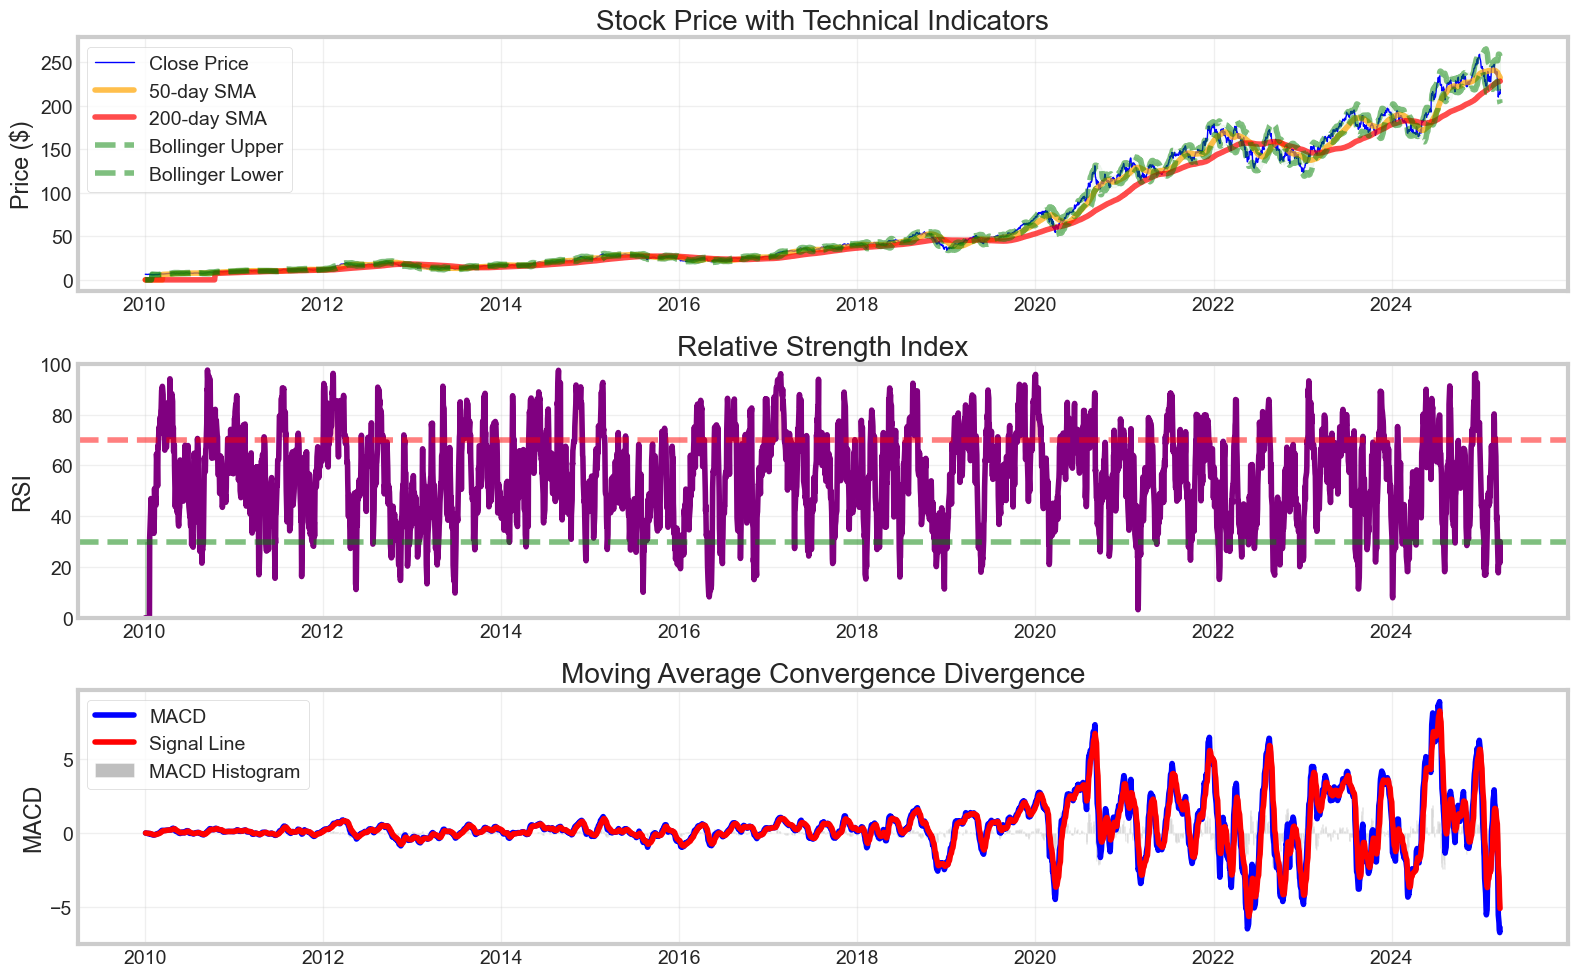


Plotting external data sources...


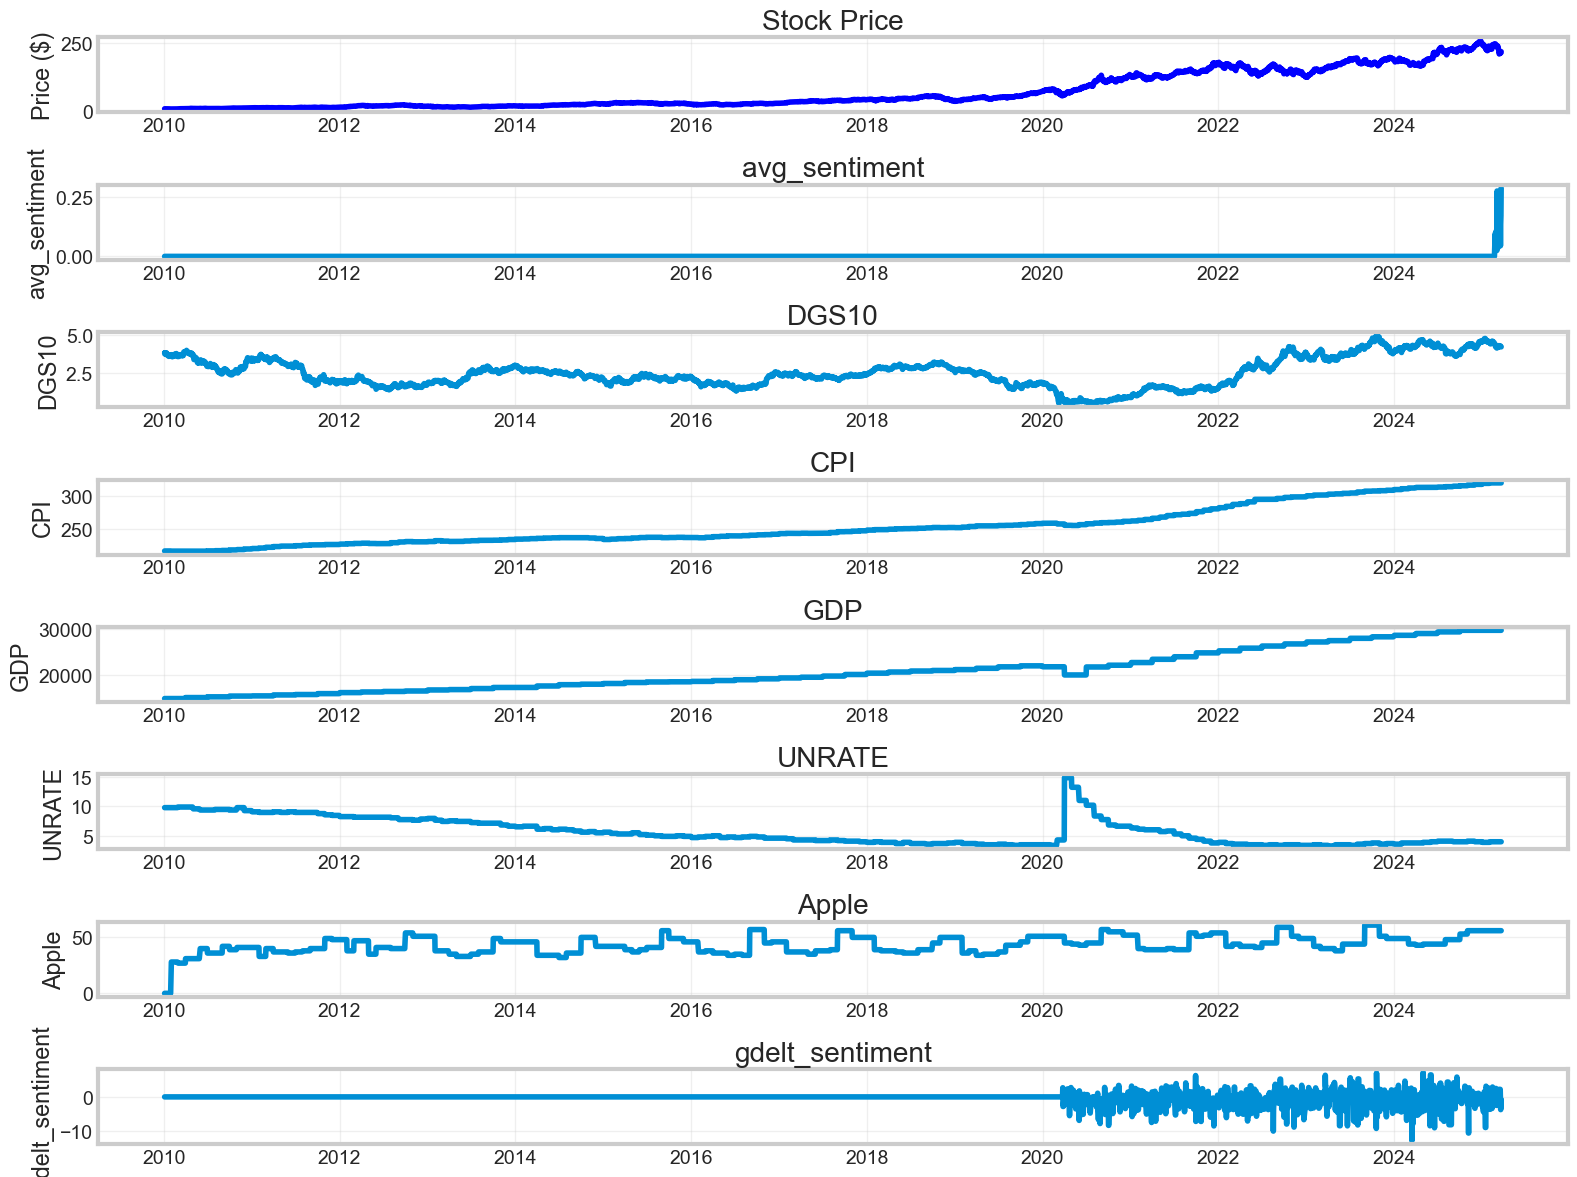


Calculating correlation matrix...


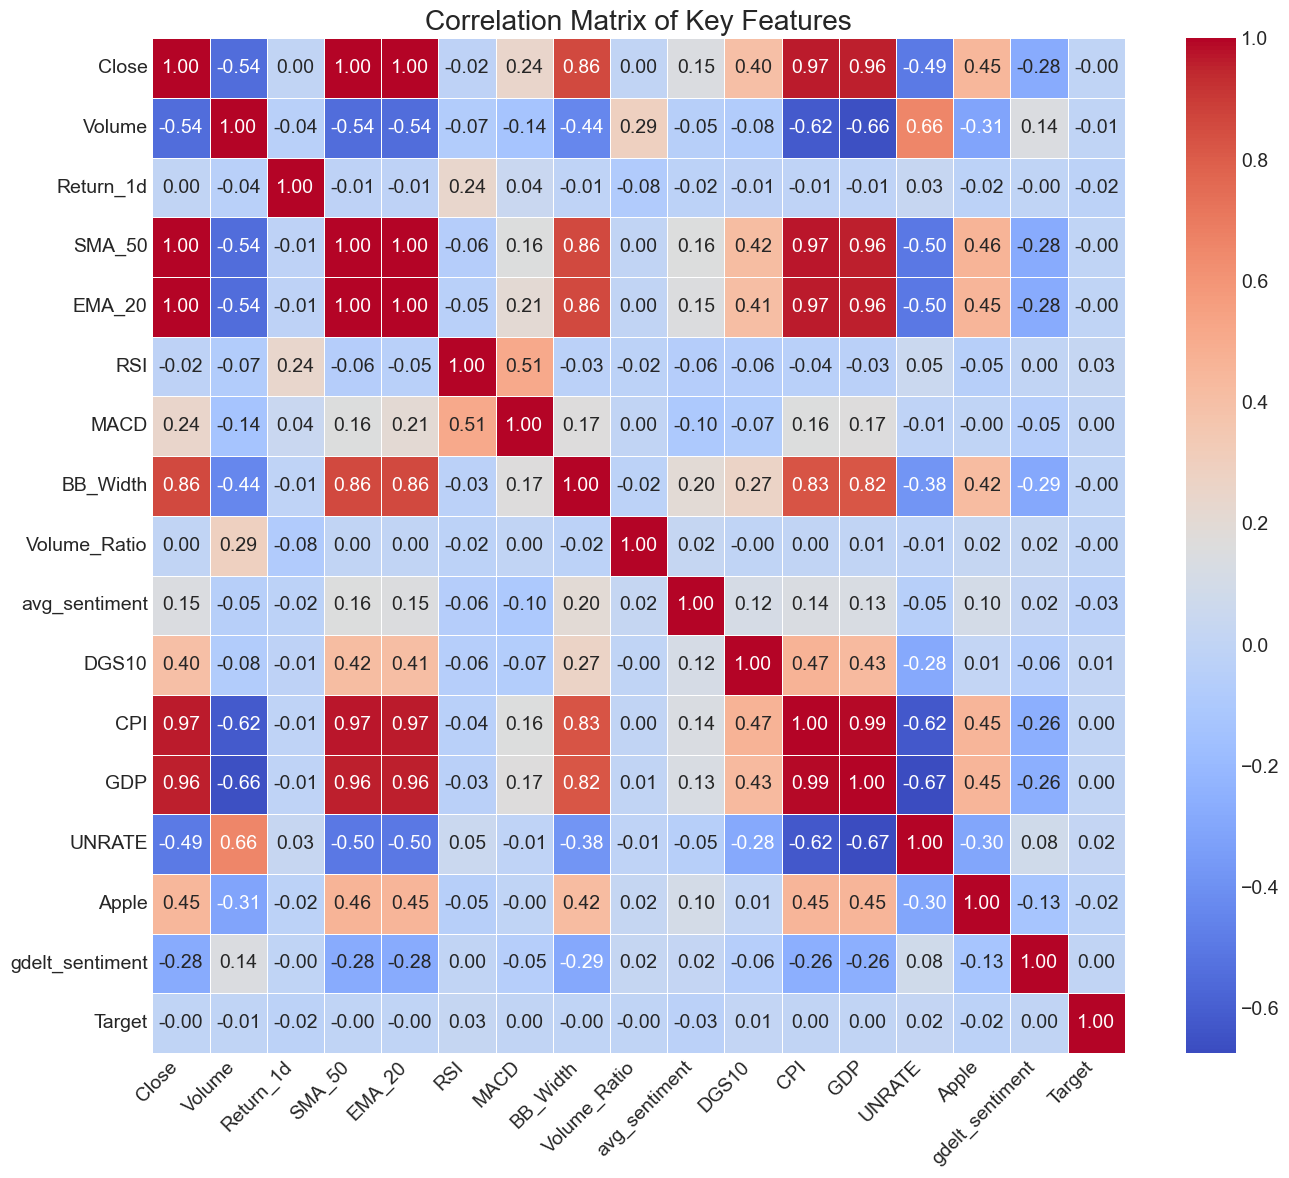


Feature Correlations with Target (next day movement):
Target             1.000000
RSI                0.025342
UNRATE             0.015736
DGS10              0.009202
GDP                0.003343
CPI                0.002589
gdelt_sentiment    0.001935
MACD               0.001212
Volume_Ratio      -0.000898
BB_Width          -0.001724
Close             -0.002767
EMA_20            -0.002768
SMA_50            -0.002780
Volume            -0.005506
Return_1d         -0.019970
Apple             -0.021806
avg_sentiment     -0.028651
Name: Target, dtype: float64


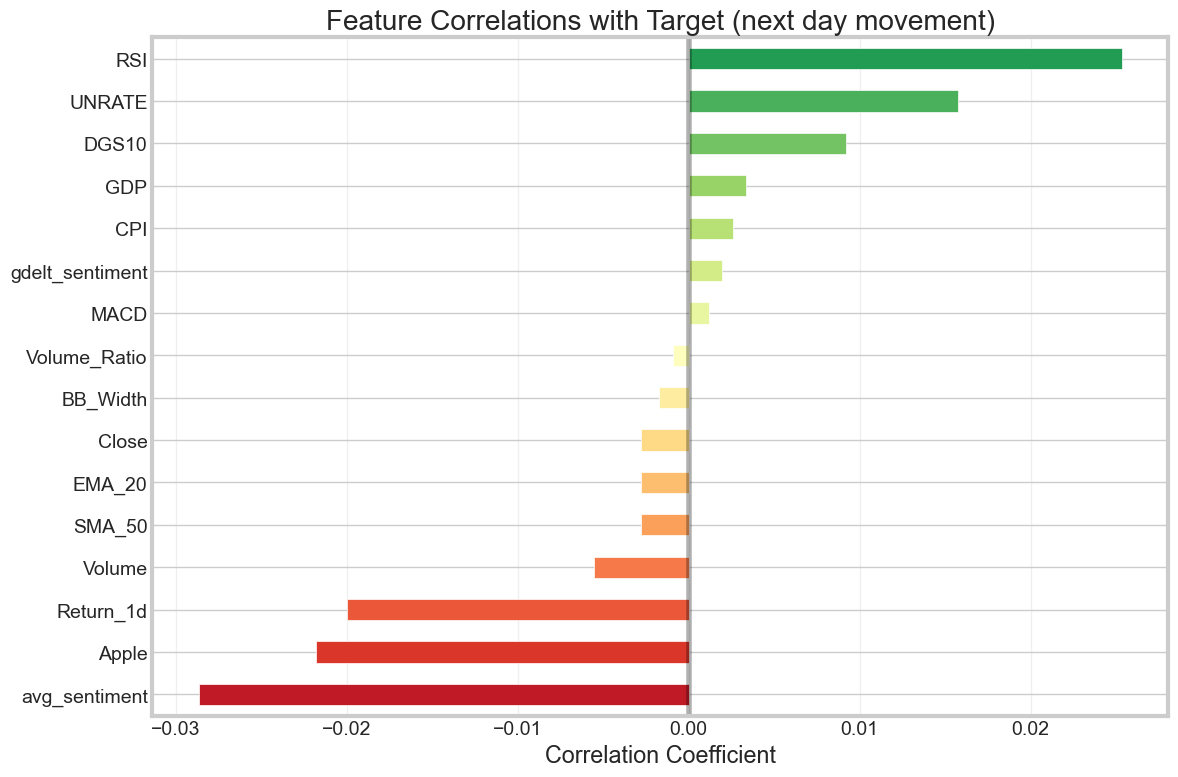


Analyzing Target Distribution...
Target Distribution:
0 (Down): 1800 samples (47.02%)
1 (Up): 2028 samples (52.98%)


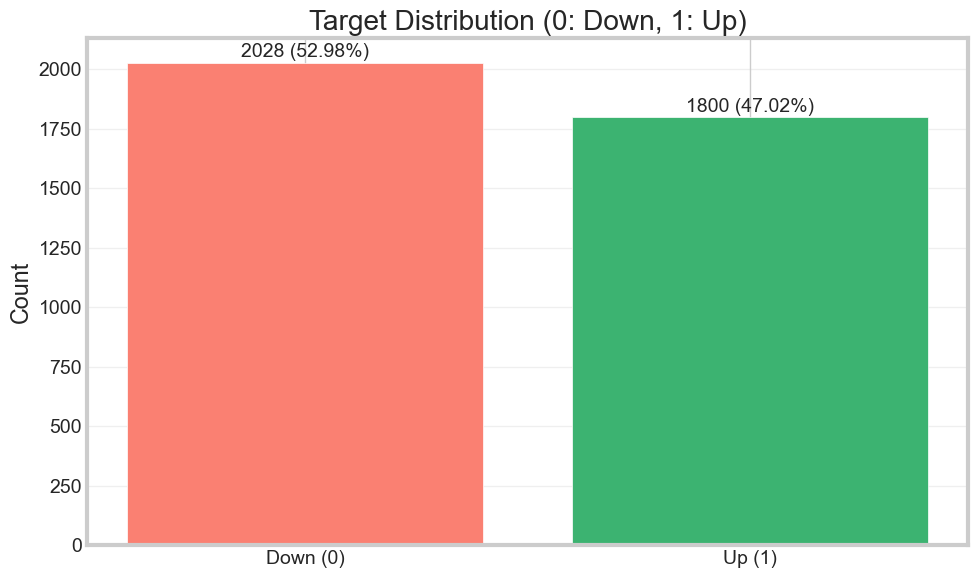

In [11]:
# Cell 7: Visualize Enhanced Dataset
def visualize_enhanced_dataset(df=None):
    """
    Visualize the enhanced dataset with technical indicators and external data
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with enhanced data. If None, will try to load from enhanced_stock_data.csv
        
    Returns:
    --------
    pandas.DataFrame
        Correlation matrix of key features
    """
    print("Visualizing enhanced dataset...")
    
    # Load data if not provided
    if df is None:
        try:
            print("Loading enhanced data...")
            df = pd.read_csv("data/enhanced_stock_data.csv", index_col=0, parse_dates=True)
            print(f"Loaded enhanced data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading enhanced data: {e}")
            return None
    
    # Make sure we have required technical indicators
    required_indicators = ['Close', 'SMA_50', 'SMA_200', 'RSI', 'MACD', 'BB_Upper', 'BB_Lower']
    missing_indicators = [indicator for indicator in required_indicators if indicator not in df.columns]
    if missing_indicators:
        print(f"Warning: Missing some required indicators: {missing_indicators}")
        print("Some visualizations may not be available")
    
    # 1. Check dataset statistics and missing values
    print("\nDataset Statistics:")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Total trading days: {len(df)}")
    
    # Check for any remaining NaN values
    na_count = df.isna().sum().sum()
    if na_count > 0:
        print(f"\nWarning: Found {na_count} NaN values in dataset")
        print("NaN counts by column:")
        for col in df.columns:
            na_col = df[col].isna().sum()
            if na_col > 0:
                print(f"  {col}: {na_col} NaNs")
    else:
        print("No NaN values found in dataset")
    
    # 2. Visualize Price with Technical Indicators
    print("\nPlotting price chart with technical indicators...")
    plt.figure(figsize=(16, 10))
    
    # Main price chart with moving averages
    plt.subplot(3, 1, 1)
    plt.plot(df.index, df['Close'], label='Close Price', color='blue', linewidth=1)
    
    if 'SMA_50' in df.columns:
        plt.plot(df.index, df['SMA_50'], label='50-day SMA', color='orange', alpha=0.7)
    if 'SMA_200' in df.columns:
        plt.plot(df.index, df['SMA_200'], label='200-day SMA', color='red', alpha=0.7)
    
    # Add Bollinger Bands if available
    if 'BB_Upper' in df.columns and 'BB_Lower' in df.columns:
        plt.plot(df.index, df['BB_Upper'], label='Bollinger Upper', color='green', linestyle='--', alpha=0.5)
        plt.plot(df.index, df['BB_Lower'], label='Bollinger Lower', color='green', linestyle='--', alpha=0.5)
        plt.fill_between(df.index, df['BB_Lower'], df['BB_Upper'], color='green', alpha=0.05)
    
    plt.title('Stock Price with Technical Indicators')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    
    # RSI subplot
    plt.subplot(3, 1, 2)
    if 'RSI' in df.columns:
        plt.plot(df.index, df['RSI'], label='RSI', color='purple')
        plt.axhline(y=70, color='red', linestyle='--', alpha=0.5)
        plt.axhline(y=30, color='green', linestyle='--', alpha=0.5)
        plt.fill_between(df.index, 70, df['RSI'], where=(df['RSI'] >= 70), color='red', alpha=0.2)
        plt.fill_between(df.index, 30, df['RSI'], where=(df['RSI'] <= 30), color='green', alpha=0.2)
        plt.title('Relative Strength Index')
        plt.ylabel('RSI')
        plt.ylim(0, 100)
    else:
        plt.text(0.5, 0.5, 'RSI data not available', ha='center', va='center')
    plt.grid(True, alpha=0.3)
    
    # MACD subplot
    plt.subplot(3, 1, 3)
    if all(col in df.columns for col in ['MACD', 'MACD_Signal', 'MACD_Hist']):
        plt.plot(df.index, df['MACD'], label='MACD', color='blue')
        plt.plot(df.index, df['MACD_Signal'], label='Signal Line', color='red')
        plt.bar(df.index, df['MACD_Hist'], label='MACD Histogram', color='gray', alpha=0.5, width=2)
        plt.title('Moving Average Convergence Divergence')
        plt.ylabel('MACD')
        plt.legend(loc='upper left')
    else:
        plt.text(0.5, 0.5, 'MACD data not available', ha='center', va='center')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Visualize External Data Sources (if available)
    external_features = [col for col in df.columns if col in ['avg_sentiment', 'DGS10', 'CPI', 'GDP', 'UNRATE', 'Apple', 'gdelt_sentiment']]
    
    if external_features:
        print("\nPlotting external data sources...")
        plt.figure(figsize=(16, 12))
        
        # Stock price subplot for reference
        plt.subplot(len(external_features) + 1, 1, 1)
        plt.plot(df.index, df['Close'], color='blue')
        plt.title('Stock Price')
        plt.ylabel('Price ($)')
        plt.grid(True, alpha=0.3)
        
        # Plot each external feature
        for i, feature in enumerate(external_features, start=2):
            plt.subplot(len(external_features) + 1, 1, i)
            plt.plot(df.index, df[feature], label=feature)
            plt.title(f'{feature}')
            plt.ylabel(feature)
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No external data features found in the dataset")
    
    # 4. Correlation Analysis (focus on key features)
    print("\nCalculating correlation matrix...")
    
    # Select relevant columns for correlation
    base_cols = ['Close', 'Volume', 'Return_1d']
    
    # Add technical indicators if available
    tech_cols = []
    for col in ['SMA_50', 'EMA_20', 'RSI', 'MACD', 'BB_Width', 'Volume_Ratio']:
        if col in df.columns:
            tech_cols.append(col)
    
    # Add external data if available
    external_cols = []
    for col in external_features:
        external_cols.append(col)
    
    # Always include target if available
    target_col = ['Target'] if 'Target' in df.columns else []
    
    # Combine columns for correlation analysis
    corr_cols = base_cols + tech_cols + external_cols + target_col
    
    # Filter to only include columns that exist in the dataset
    corr_cols = [col for col in corr_cols if col in df.columns]
    
    if len(corr_cols) > 1:  # Need at least 2 columns for correlation
        corr_matrix = df[corr_cols].corr()
        
        # Plot correlation matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix of Key Features')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # If Target is in correlation matrix, print correlations with Target
        if 'Target' in corr_cols:
            print("\nFeature Correlations with Target (next day movement):")
            target_corrs = corr_matrix['Target'].sort_values(ascending=False)
            print(target_corrs)
            
            # Plot top correlations with Target
            plt.figure(figsize=(12, 8))
            target_corrs.drop('Target').sort_values().plot(kind='barh', color=sns.color_palette("RdYlGn", len(target_corrs)))
            plt.title('Feature Correlations with Target (next day movement)')
            plt.xlabel('Correlation Coefficient')
            plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        print("Not enough columns for correlation analysis")
        corr_matrix = pd.DataFrame()
    
    # 5. Target Distribution (if available)
    if 'Target' in df.columns:
        print("\nAnalyzing Target Distribution...")
        target_counts = df['Target'].value_counts()
        target_pcts = df['Target'].value_counts(normalize=True) * 100
        
        print(f"Target Distribution:")
        print(f"0 (Down): {target_counts[0]} samples ({target_pcts[0]:.2f}%)")
        print(f"1 (Up): {target_counts[1]} samples ({target_pcts[1]:.2f}%)")
        
        plt.figure(figsize=(10, 6))
        plt.bar(['Down (0)', 'Up (1)'], target_counts.values, color=['salmon', 'mediumseagreen'])
        plt.title('Target Distribution (0: Down, 1: Up)')
        plt.ylabel('Count')
        plt.grid(axis='y', alpha=0.3)
        
        # Add count and percentage labels
        for i, count in enumerate(target_counts.values):
            plt.text(i, count + 5, f"{count} ({target_pcts.values[i]:.2f}%)", 
                    ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    else:
        print("Target variable not found in dataset")
    
    return corr_matrix

# Execute visualization
corr_matrix = visualize_enhanced_dataset()

# If correlation matrix is calculated, optionally display it again in a nicer format
if corr_matrix is not None and not corr_matrix.empty:
    # Optional: Format and display the correlation matrix again
    pass

Performing simplified feature engineering...
Loading enhanced data...
Loaded enhanced data with shape (3828, 44)

1. Creating additional technical indicators...
Calculating On-Balance Volume (OBV)...
Calculating Stochastic Oscillator...
Calculating Rate of Change (ROC)...

2. Creating feature transformations...
Calculating Log Returns...
Calculating Volatility features...
Calculating Momentum features...
Calculating Crossover Signals...
Calculating Bollinger Band Position...

3. Creating time-based features...

Found 63 NaN values across all columns
Columns with NaNs:
  %K: 13 NaNs
  %D: 15 NaNs
  ROC_5: 5 NaNs
  ROC_10: 10 NaNs
  Log_Return_1d: 1 NaNs
  Volatility_10d: 9 NaNs
  Momentum_10d: 10 NaNs
Filling NaNs with forward fill and zeros...

Feature engineered data saved to data/feature_engineered_data.csv with shape (3828, 58)

Analyzing features and creating final dataset...

1. Cleaning data for analysis...
Found infinities in columns: ['BB_Position']
Replacing infinities with Na

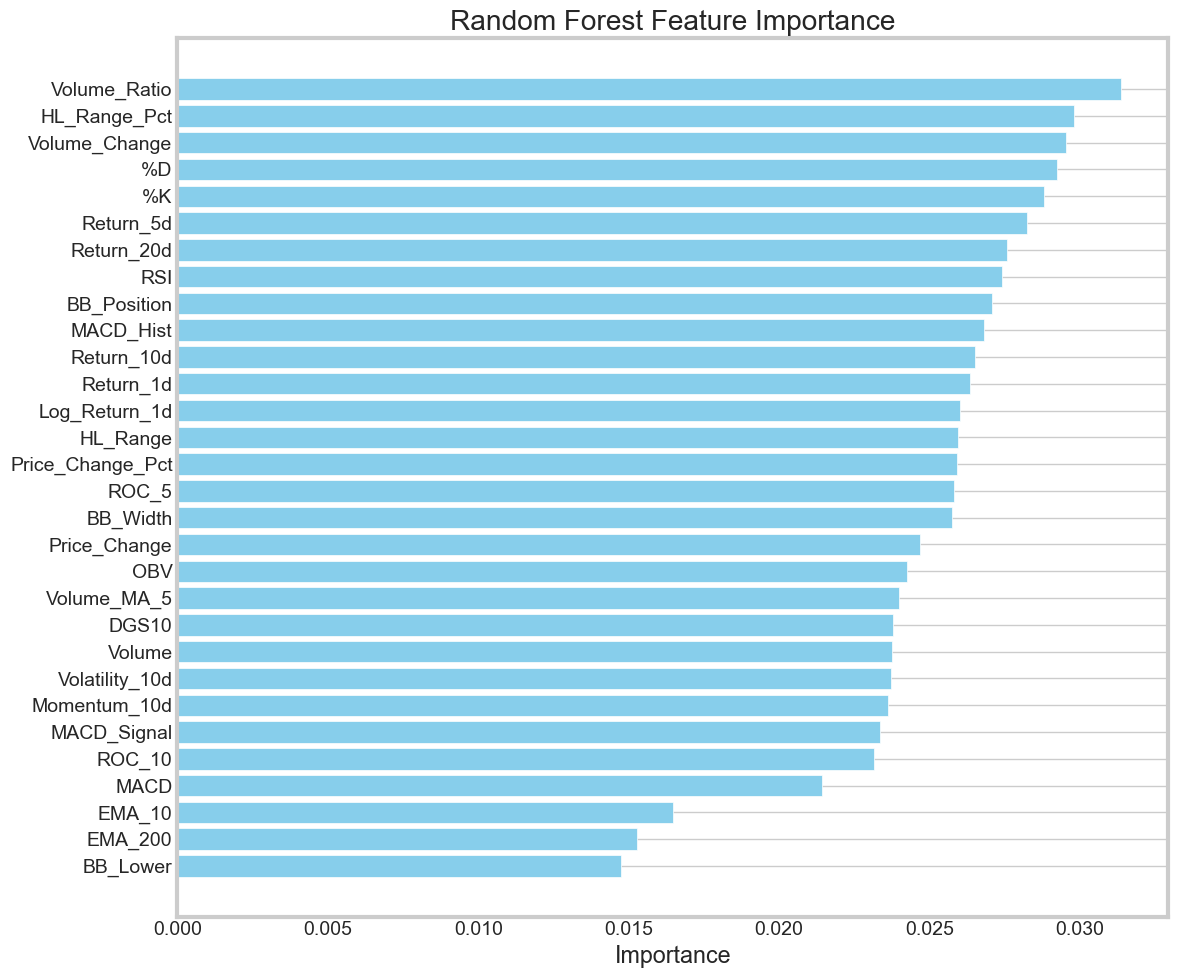


3. Correlation with Target


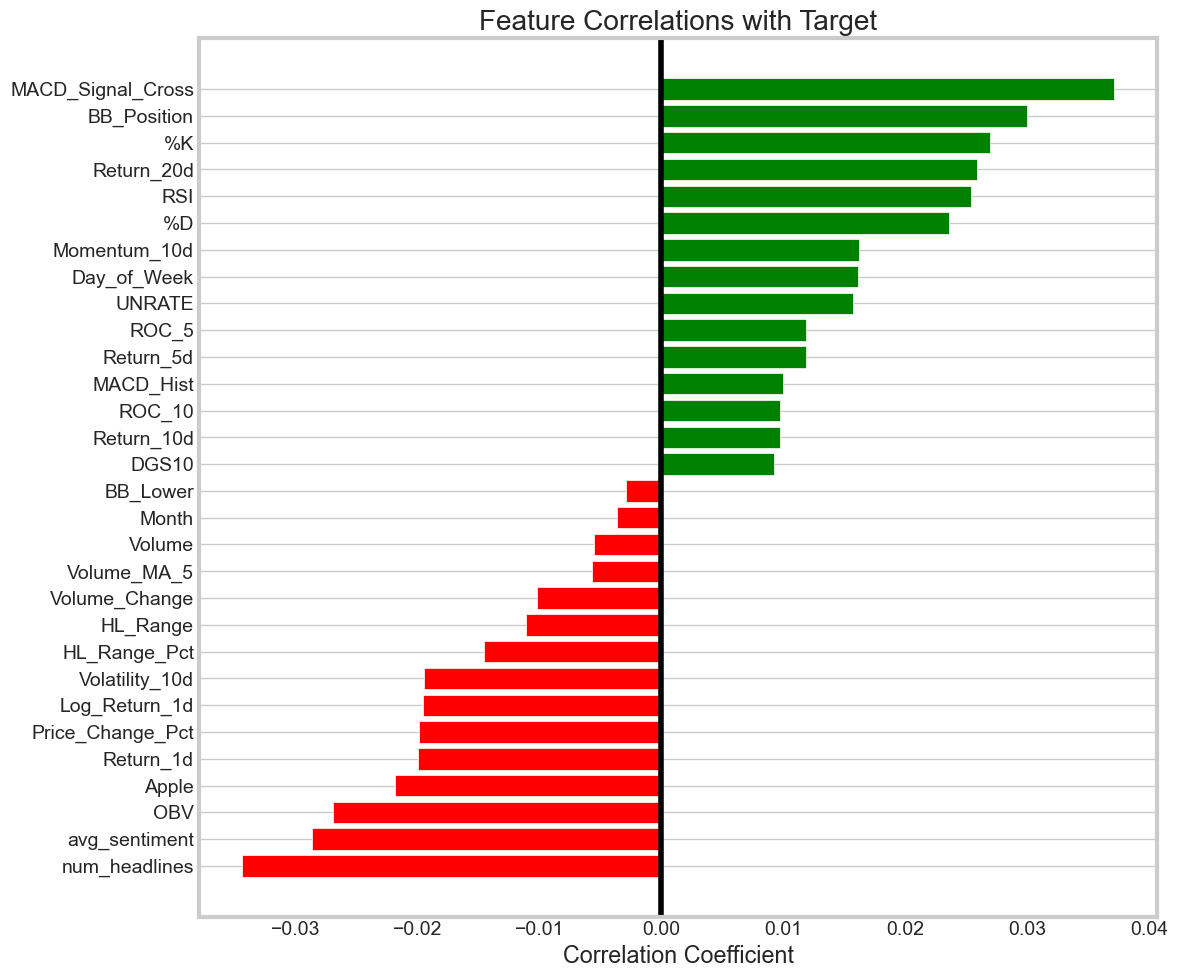


4. Creating Final Feature Set

Selected features for final dataset:
1. Volume_Ratio
2. HL_Range_Pct
3. Volume_Change
4. %D
5. %K
6. Return_5d
7. Return_20d
8. RSI
9. BB_Position
10. MACD_Hist
11. Return_10d
12. Return_1d
13. Log_Return_1d
14. HL_Range
15. Price_Change_Pct
16. ROC_5
17. BB_Width
18. Price_Change
19. OBV
20. Volume_MA_5
21. DGS10
22. Volume
23. Volatility_10d
24. Momentum_10d
25. MACD_Signal
26. ROC_10
27. MACD
28. EMA_10
29. EMA_200
30. BB_Lower

Final modeling data saved to data/final_modeling_data.csv with shape (3828, 32)


In [57]:
# Cell 8: Simplified Feature Engineering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')

def simplified_feature_engineering(df=None):
    """
    Perform simplified feature engineering on the enhanced dataset
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with enhanced data. If None, will try to load from enhanced_stock_data.csv
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional engineered features
    """
    print("Performing simplified feature engineering...")
    
    # Load data if not provided
    if df is None:
        try:
            print("Loading enhanced data...")
            df = pd.read_csv("data/enhanced_stock_data.csv", index_col=0, parse_dates=True)
            print(f"Loaded enhanced data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading enhanced data: {e}")
            return None
    
    # Make a copy to avoid modifying the original
    feature_df = df.copy()
    
    # 1. Additional Technical Indicators
    print("\n1. Creating additional technical indicators...")
    
    # On-Balance Volume (OBV)
    print("Calculating On-Balance Volume (OBV)...")
    feature_df['OBV'] = 0
    for i in range(1, len(feature_df)):
        if feature_df['Close'].iloc[i] > feature_df['Close'].iloc[i-1]:
            feature_df['OBV'].iloc[i] = feature_df['OBV'].iloc[i-1] + feature_df['Volume'].iloc[i]
        elif feature_df['Close'].iloc[i] < feature_df['Close'].iloc[i-1]:
            feature_df['OBV'].iloc[i] = feature_df['OBV'].iloc[i-1] - feature_df['Volume'].iloc[i]
        else:
            feature_df['OBV'].iloc[i] = feature_df['OBV'].iloc[i-1]
    
    # Stochastic Oscillator - Fast (%K) and Slow (%D)
    print("Calculating Stochastic Oscillator...")
    low_14 = feature_df['Low'].rolling(window=14).min()
    high_14 = feature_df['High'].rolling(window=14).max()
    feature_df['%K'] = 100 * ((feature_df['Close'] - low_14) / (high_14 - low_14))
    feature_df['%D'] = feature_df['%K'].rolling(window=3).mean()
    
    # Rate of Change (ROC)
    print("Calculating Rate of Change (ROC)...")
    feature_df['ROC_5'] = feature_df['Close'].pct_change(periods=5) * 100
    feature_df['ROC_10'] = feature_df['Close'].pct_change(periods=10) * 100
    
    # 2. Feature Transformations
    print("\n2. Creating feature transformations...")
    
    # Log Returns instead of simple returns
    print("Calculating Log Returns...")
    feature_df['Log_Return_1d'] = np.log(feature_df['Close'] / feature_df['Close'].shift(1))
    
    # Volatility features - rolling standard deviation of returns
    print("Calculating Volatility features...")
    feature_df['Volatility_10d'] = feature_df['Return_1d'].rolling(window=10).std()
    
    # Momentum features (current price / price n days ago)
    print("Calculating Momentum features...")
    feature_df['Momentum_10d'] = feature_df['Close'] / feature_df['Close'].shift(10)
    
    # Crossover signals
    print("Calculating Crossover Signals...")
    feature_df['SMA_50_200_Cross'] = (feature_df['SMA_50'] > feature_df['SMA_200']).astype(int)
    feature_df['MACD_Signal_Cross'] = (feature_df['MACD'] > feature_df['MACD_Signal']).astype(int)
    
    # Bollinger Band position (where price is within bands)
    print("Calculating Bollinger Band Position...")
    feature_df['BB_Position'] = (feature_df['Close'] - feature_df['BB_Lower']) / (feature_df['BB_Upper'] - feature_df['BB_Lower'])
    
    # 3. Time-based Features
    print("\n3. Creating time-based features...")
    feature_df['Day_of_Week'] = feature_df.index.dayofweek
    feature_df['Month'] = feature_df.index.month
    feature_df['Quarter'] = feature_df.index.quarter
    
    # Check for and handle NaNs
    na_count_before = feature_df.isna().sum().sum()
    if na_count_before > 0:
        print(f"\nFound {na_count_before} NaN values across all columns")
        
        # Show NaN counts by column
        nan_columns = feature_df.columns[feature_df.isna().any()].tolist()
        print("Columns with NaNs:")
        for col in nan_columns:
            na_count = feature_df[col].isna().sum()
            if na_count > 0:
                print(f"  {col}: {na_count} NaNs")
        
        # Forward fill and replace remaining NaNs with zeros
        print("Filling NaNs with forward fill and zeros...")
        feature_df = feature_df.fillna(method='ffill').fillna(0)
    
    # Save to CSV
    feature_df.to_csv("data/feature_engineered_data.csv")
    print(f"\nFeature engineered data saved to data/feature_engineered_data.csv with shape {feature_df.shape}")
    
    return feature_df

def analyze_features(df=None, target_col='Target'):
    """
    Analyze features and create a final dataset with selected features
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with feature engineered data
    target_col : str
        Name of the target column
        
    Returns:
    --------
    pandas.DataFrame
        Final dataset with selected features
    """
    print("\nAnalyzing features and creating final dataset...")
    
    # Load data if not provided
    if df is None:
        try:
            print("Loading feature engineered data...")
            df = pd.read_csv("data/feature_engineered_data.csv", index_col=0, parse_dates=True)
            print(f"Loaded feature engineered data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading feature engineered data: {e}")
            return None
    
    # Make a copy to avoid modifying the original
    analysis_df = df.copy()
    
    # 1. Data Cleaning for Analysis
    print("\n1. Cleaning data for analysis...")
    
    # Check for and handle infinities and extreme values
    numeric_cols = analysis_df.select_dtypes(include=['number']).columns
    
    # First check for infinities
    inf_counts = np.isinf(analysis_df[numeric_cols]).sum()
    inf_cols = inf_counts[inf_counts > 0].index.tolist()
    
    if inf_cols:
        print(f"Found infinities in columns: {inf_cols}")
        print("Replacing infinities with NaN...")
        for col in inf_cols:
            analysis_df[col] = analysis_df[col].replace([np.inf, -np.inf], np.nan)
    
    # Check for extremely large values
    for col in numeric_cols:
        max_val = analysis_df[col].max()
        min_val = analysis_df[col].min()
        if max_val > 1e30 or min_val < -1e30:
            print(f"Column {col} has extreme values: min={min_val}, max={max_val}")
            print(f"Clipping values in column {col}...")
            analysis_df[col] = analysis_df[col].clip(-1e30, 1e30)
    
    # Fill NaN values
    nan_count = analysis_df[numeric_cols].isna().sum().sum()
    if nan_count > 0:
        print(f"Filling {nan_count} NaN values...")
        analysis_df = analysis_df.fillna(method='ffill').fillna(0)
    
    # Make sure target column is not NaN
    if target_col in analysis_df.columns and analysis_df[target_col].isna().any():
        print(f"Warning: Target column {target_col} contains NaN values. Dropping those rows.")
        analysis_df = analysis_df.dropna(subset=[target_col])
    
    # 2. Random Forest Feature Importance
    print("\n2. Random Forest Feature Importance")
    
    # Separate features and target
    feature_cols = analysis_df.select_dtypes(include=['number']).columns.tolist()
    if 'group' in feature_cols:
        feature_cols.remove('group')  # Remove group column
    if target_col in feature_cols:
        feature_cols.remove(target_col)  # Remove target column from features
    
    X = analysis_df[feature_cols]
    y = analysis_df[target_col]
    
    # Double check for any remaining issues
    if X.isna().any().any():
        print("Warning: Features still contain NaN values. Filling with zeros.")
        X = X.fillna(0)
    
    if np.isinf(X).any().any():
        print("Warning: Features still contain infinity values. Replacing with zeros.")
        X = X.replace([np.inf, -np.inf], 0)
    
    try:
        # Convert to float64 to avoid potential dtype issues
        X = X.astype('float64')
        
        # Fit a Random Forest model with reduced complexity to avoid memory issues
        print("Fitting Random Forest model...")
        rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
        rf.fit(X, y)
        
        # Get feature importances
        importance_df = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        # Plot top 20 features or all features if less than 20
        plt.figure(figsize=(12, 10))
        top_features = importance_df.head(min(30, len(importance_df)))
        plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
        plt.xlabel('Importance')
        plt.title('Random Forest Feature Importance')
        plt.gca().invert_yaxis()  # Invert y-axis to have highest importance at the top
        plt.grid(axis='x')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error fitting Random Forest model: {e}")
        print("Proceeding with correlation analysis only...")
        importance_df = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': np.ones(len(feature_cols)) / len(feature_cols)  # Equal importance
        })
    
    # 3. Correlation with Target
    print("\n3. Correlation with Target")
    
    try:
        # Calculate correlation with target
        correlations = X.corrwith(analysis_df[target_col]).sort_values(ascending=False)
        
        # Plot top positive and negative correlations
        plt.figure(figsize=(12, 10))
        n_corrs = min(30, len(correlations))
        
        # Get top positive and negative correlations
        top_pos = correlations.nlargest(n_corrs // 2)
        top_neg = correlations.nsmallest(n_corrs // 2)
        
        # Combine and sort for plotting
        top_corrs = pd.concat([top_pos, top_neg]).sort_values()
        
        plt.barh(top_corrs.index, top_corrs.values, 
                 color=np.where(top_corrs > 0, 'green', 'red'))
        plt.axvline(x=0, color='black', linestyle='-')
        plt.title('Feature Correlations with Target')
        plt.xlabel('Correlation Coefficient')
        plt.grid(axis='x')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error calculating correlations: {e}")
        correlations = pd.Series(0, index=feature_cols)
    
    # 4. Feature Selection
    print("\n4. Creating Final Feature Set")
    
    # Select features based on feature importance or correlation with target
    if len(importance_df) > 0:
        # Take top 20 features by importance if available
        top_n = min(30, len(importance_df))
        selected_features = importance_df.head(top_n)['Feature'].tolist()
    else:
        # Fallback to correlation-based selection
        top_n = min(30, len(correlations))
        abs_corr = correlations.abs().sort_values(ascending=False)
        selected_features = abs_corr.head(top_n).index.tolist()
    
    # Add group and target columns if they exist
    if 'group' in analysis_df.columns:
        selected_features.append('group')
    if target_col in analysis_df.columns:
        selected_features.append(target_col)
    
    # Create final dataset
    final_df = analysis_df[selected_features].copy()
    
    # Print selected features
    print("\nSelected features for final dataset:")
    for i, feat in enumerate(selected_features, 1):
        if feat not in ['group', target_col]:
            print(f"{i}. {feat}")
    
    # Save to CSV
    final_df.to_csv("data/final_modeling_data.csv")
    print(f"\nFinal modeling data saved to data/final_modeling_data.csv with shape {final_df.shape}")
    
    return final_df

# Execute functions
feature_engineered_df = simplified_feature_engineering()
final_df = analyze_features(feature_engineered_df)

In [37]:
print(final_df.head())

            Volume_Ratio  HL_Range_Pct  Volume_Change   %D   %K  Return_5d  \
Date                                                                         
2010-01-04       0.00000      0.993298       0.000000  0.0  0.0        0.0   
2010-01-05       0.00000      1.090407       0.219098  0.0  0.0        0.0   
2010-01-06       0.00000      2.089751      -0.082646  0.0  0.0        0.0   
2010-01-07       0.00000      1.393159      -0.135882  0.0  0.0        0.0   
2010-01-08       0.86998      1.397997      -0.061871  0.0  0.0        0.0   

            Return_20d  RSI  BB_Position  MACD_Hist  ...  Volatility_10d  \
Date                                                 ...                   
2010-01-04         0.0  0.0          0.0   0.000000  ...             0.0   
2010-01-05         0.0  0.0          0.0   0.000710  ...             0.0   
2010-01-06         0.0  0.0          0.0  -0.005432  ...             0.0   
2010-01-07         0.0  0.0          0.0  -0.009735  ...             0.0 

Creating supervised autoencoder features...
Loading final modeling data...
Loaded data with shape (3828, 58)

1. Preparing data for autoencoder...

2. Building supervised autoencoder model...

Model Summary:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 56)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gaussian_noise_2              │ (None, 56)                │               0 │ input_layer_2[0][0]        │
│ (GaussianNoise)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 64)                │           3,648 │ gaussian_noise_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_9 (Dropout)           │ (None, 64)                │               0 │ dense_11[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 32)                │           2,080 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bottleneck (Dense)            │ (None, 8)                 │             264 │ dense_12[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_13 (Dense)              │ (None, 32)                │             288 │ bottleneck[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_10 (Dropout)          │ (None, 32)                │               0 │ dense_13[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_15 (Dense)              │ (None, 16)                │             144 │ bottleneck[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_14 (Dense)              │ (None, 64)                │           2,112 │ dropout_10[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_11 (Dropout)          │ (None, 16)                │               0 │ dense_15[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reconstruction (Dense)        │ (None, 56)                │           3,640 │ dense_14[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classification (Dense)        │ (None, 1)                 │              17 │ dropout_11[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)


3. Training supervised autoencoder...
Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - classification_accuracy: 0.5107 - classification_loss: 0.6965 - loss: 0.6978 - reconstruction_loss: 0.6983 - val_classification_accuracy: 0.4713 - val_classification_loss: 0.7503 - val_loss: 1.0408 - val_reconstruction_loss: 1.1722
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_accuracy: 0.5139 - classification_loss: 0.6970 - loss: 0.5258 - reconstruction_loss: 0.4524 - val_classification_accuracy: 0.4856 - val_classification_loss: 0.7020 - val_loss: 0.8978 - val_reconstruction_loss: 0.9884
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_accuracy: 0.5195 - classification_loss: 0.6954 - loss: 0.4728 - reconstruction_loss: 0.3774 - val_classification_accuracy: 0.5065 - val_classification_loss: 0.6958 - val_loss: 0.9020 - val_reconstruction_loss: 0.9973
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_accuracy: 0.5162 - classification_loss: 0.

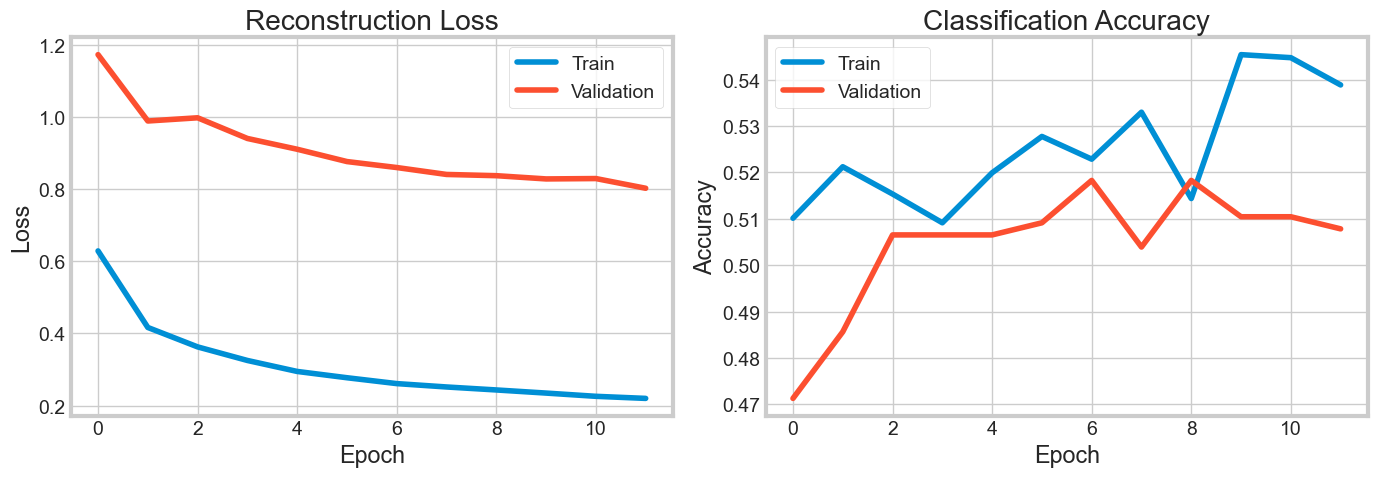


4. Extracting bottleneck features...
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step

5. Merging bottleneck features with original features...
Autoencoder features saved to data/autoencoder_features.csv with shape (3828, 66)

6. Analyzing importance of autoencoder features...


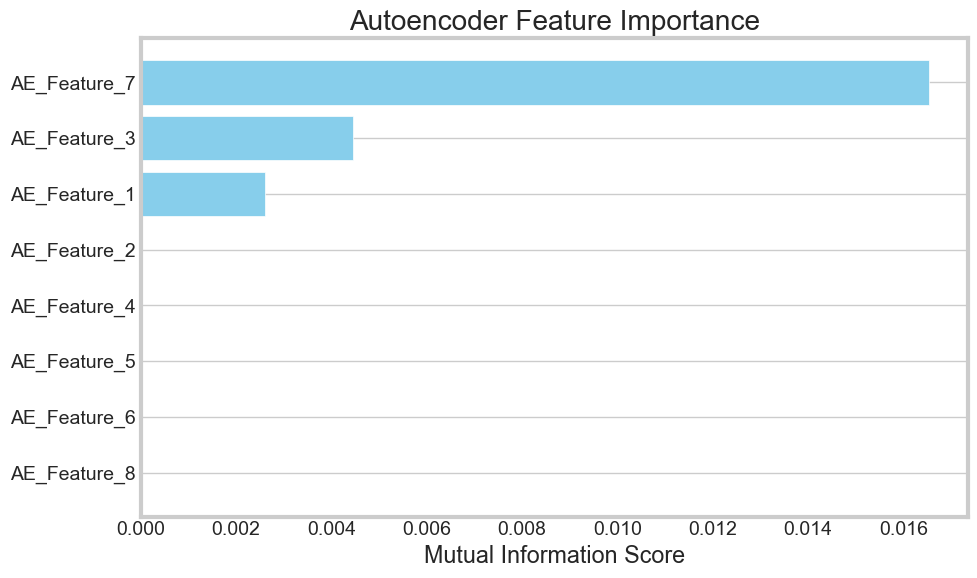


Top autoencoder features by mutual information:
1. AE_Feature_7: 0.016532
2. AE_Feature_3: 0.004460
3. AE_Feature_1: 0.002608
4. AE_Feature_2: 0.000000
5. AE_Feature_4: 0.000000

Creating purged time-series CV folds...
Fold 1:
  Train: 3063 samples
  Test: 765 samples
Fold 2:
  Train: 3032 samples
  Test: 765 samples
Fold 3:
  Train: 3032 samples
  Test: 765 samples
Fold 4:
  Train: 3032 samples
  Test: 765 samples
Fold 5:
  Train: 3032 samples
  Test: 765 samples


In [39]:
# Cell 9: Advanced Feature Engineering with Supervised Autoencoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def create_supervised_autoencoder_features(df=None, 
                                          bottleneck_dim=8, 
                                          epochs=30, 
                                          batch_size=64, 
                                          validation_split=0.2,
                                          noise_std=0.01):
    """
    Create features using a supervised autoencoder as described in Phase 2
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with the feature engineered data
    bottleneck_dim : int
        Dimension of the bottleneck layer
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    validation_split : float
        Fraction of data to use for validation
    noise_std : float
        Standard deviation of Gaussian noise added to input
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with original features and autoencoder features
    """
    print("Creating supervised autoencoder features...")
    
    # Load data if not provided
    if df is None:
        try:
            print("Loading final modeling data...")
            # df = pd.read_csv("data/final_modeling_data.csv", index_col=0, parse_dates=True)
            df = pd.read_csv("data/feature_engineered_data.csv", index_col=0, parse_dates=True)
            print(f"Loaded data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading final modeling data: {e}")
            try:
                print("Attempting to load feature engineered data...")
                df = pd.read_csv("data/feature_engineered_data.csv", index_col=0, parse_dates=True)
                print(f"Loaded feature engineered data with shape {df.shape}")
            except Exception as e2:
                print(f"Error loading feature engineered data: {e2}")
                return None
    
    # Make a copy to avoid modifying the original
    ae_df = df.copy()
    
    # 1. Data Preparation
    print("\n1. Preparing data for autoencoder...")
    
    # Separate features and target
    if 'Target' in ae_df.columns:
        target_col = 'Target'
    else:
        print("Target column not found, cannot build supervised autoencoder.")
        return None
    
    # Select numeric columns only
    numeric_cols = ae_df.select_dtypes(include=['number']).columns.tolist()
    
    # Remove target and group from feature columns
    feature_cols = [col for col in numeric_cols if col != target_col and col != 'group']
    
    # Check if we have enough features
    if len(feature_cols) < 5:
        print(f"Too few features ({len(feature_cols)}) for autoencoder. Need at least 5.")
        return None
    
    # Extract features and target
    X = ae_df[feature_cols].values
    y = ae_df[target_col].values
    
    # Handle infinities and large values
    X = np.nan_to_num(X, nan=0, posinf=1e10, neginf=-1e10)
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. Build Supervised Autoencoder
    print("\n2. Building supervised autoencoder model...")
    
    try:
        # Input layer
        input_layer = Input(shape=(X_scaled.shape[1],))
        
        # Add Gaussian noise for robustness
        noisy_input = GaussianNoise(noise_std)(input_layer)
        
        # Encoder layers with swish activation as mentioned in the requirements
        encoder = Dense(64, activation='swish')(noisy_input)
        encoder = Dropout(0.2)(encoder)
        encoder = Dense(32, activation='swish')(encoder)
        
        # Bottleneck layer
        bottleneck = Dense(bottleneck_dim, activation='swish', name='bottleneck')(encoder)
        
        # Decoder layers
        decoder = Dense(32, activation='swish')(bottleneck)
        decoder = Dropout(0.2)(decoder)
        decoder = Dense(64, activation='swish')(decoder)
        
        # Output layer for reconstruction
        reconstruction = Dense(X_scaled.shape[1], activation='linear', name='reconstruction')(decoder)
        
        # Supervised branch for classification
        classifier = Dense(16, activation='swish')(bottleneck)
        classifier = Dropout(0.2)(classifier)
        
        # Output layer for classification
        classification = Dense(1, activation='sigmoid', name='classification')(classifier)
        
        # Create the model with both outputs
        model = Model(inputs=input_layer, outputs=[reconstruction, classification])
        
        # Compile the model with appropriate loss functions
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss={
                'reconstruction': 'mse',  # Mean squared error for reconstruction
                'classification': 'binary_crossentropy'  # Binary cross-entropy for classification
            },
            loss_weights={
                'reconstruction': 0.7,  # Weighting for reconstruction loss
                'classification': 0.3  # Weighting for classification loss
            },
            metrics={
                'classification': 'accuracy'  # Track accuracy for classification task
            }
        )
        
        # Print model summary
        print("\nModel Summary:")
        model.summary()
    
        # 3. Train the model
        print("\n3. Training supervised autoencoder...")
        
        # Set up early stopping to prevent overfitting
        early_stopping = EarlyStopping(
            monitor='val_classification_accuracy',
            patience=5,
            restore_best_weights=True,
            mode='max'
        )
        
        # Train the model
        history = model.fit(
            X_scaled, 
            {'reconstruction': X_scaled, 'classification': y},
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=[early_stopping],
            verbose=1
        )
        
        # Plot training history
        plt.figure(figsize=(14, 5))
        
        # Plot reconstruction loss
        plt.subplot(1, 2, 1)
        plt.plot(history.history['reconstruction_loss'], label='Train')
        plt.plot(history.history['val_reconstruction_loss'], label='Validation')
        plt.title('Reconstruction Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
        # Plot classification accuracy
        plt.subplot(1, 2, 2)
        plt.plot(history.history['classification_accuracy'], label='Train')
        plt.plot(history.history['val_classification_accuracy'], label='Validation')
        plt.title('Classification Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # 4. Extract bottleneck features
        print("\n4. Extracting bottleneck features...")
        
        # Create a model that outputs the bottleneck layer
        bottleneck_model = Model(inputs=model.input, outputs=model.get_layer('bottleneck').output)
        
        # Extract bottleneck features
        bottleneck_features = bottleneck_model.predict(X_scaled)
        
        # Create a DataFrame with bottleneck features
        bottleneck_df = pd.DataFrame(
            bottleneck_features,
            columns=[f'AE_Feature_{i+1}' for i in range(bottleneck_dim)],
            index=ae_df.index
        )
        
        # 5. Merge bottleneck features with original features
        print("\n5. Merging bottleneck features with original features...")
        final_df = pd.concat([ae_df, bottleneck_df], axis=1)
        
        # Fill NaN values that might have been created
        final_df = final_df.fillna(method='ffill').fillna(0)
        
        # Save to CSV
        final_df.to_csv("data/autoencoder_features.csv")
        print(f"Autoencoder features saved to data/autoencoder_features.csv with shape {final_df.shape}")
        
        # 6. Feature Importance Analysis for new features
        print("\n6. Analyzing importance of autoencoder features...")
        
        # Calculate mutual information between features and target
        try:
            # Prepare data
            X_features = final_df[[col for col in final_df.columns if col.startswith('AE_Feature')]]
            y_target = final_df[target_col]
            
            # Calculate mutual information
            mi_scores = mutual_info_classif(X_features, y_target, random_state=42)
            
            # Create DataFrame with scores
            mi_df = pd.DataFrame({
                'Feature': X_features.columns,
                'MI_Score': mi_scores
            }).sort_values('MI_Score', ascending=False)
            
            # Plot autoencoder feature importance
            plt.figure(figsize=(10, 6))
            plt.barh(mi_df['Feature'], mi_df['MI_Score'], color='skyblue')
            plt.xlabel('Mutual Information Score')
            plt.title('Autoencoder Feature Importance')
            plt.gca().invert_yaxis()
            plt.grid(axis='x')
            plt.tight_layout()
            plt.show()
            
            # Print top autoencoder features
            print("\nTop autoencoder features by mutual information:")
            for i, (_, row) in enumerate(mi_df.head().iterrows(), 1):
                print(f"{i}. {row['Feature']}: {row['MI_Score']:.6f}")
        
        except Exception as e:
            print(f"Error in feature importance analysis: {e}")
        
        return final_df
    
    except Exception as e:
        print(f"Error building or training autoencoder: {e}")
        print("Could not create autoencoder features.")
        return ae_df

def create_purged_cv_folds(df, target_col='Target', n_splits=5, group_gap=1, embargo_pct=0.01):
    """
    Create purged and embargoed time series cross-validation folds
    as described in Phase 2 requirements
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with features and target
    target_col : str
        Name of the target column
    n_splits : int
        Number of cross-validation splits
    group_gap : int
        Number of groups to skip between train and test sets
    embargo_pct : float
        Percentage of training data to embargo
        
    Returns:
    --------
    list
        List of tuples (train_indices, test_indices)
    """
    print("\nCreating purged time-series CV folds...")
    
    # Check if group column exists
    if 'group' not in df.columns:
        print("Group column not found. Creating group column based on date index...")
        df = df.copy()
        df['group'] = pd.Series(df.index.date, index=df.index)
    
    # Get unique groups in chronological order
    groups = df['group'].unique()
    groups.sort()
    
    # Calculate test size
    test_size = len(groups) // n_splits
    
    # Create folds
    folds = []
    for i in range(n_splits):
        # Define test groups
        test_start_idx = i * test_size
        test_end_idx = min((i + 1) * test_size, len(groups))
        test_groups = groups[test_start_idx:test_end_idx]
        
        # Define train groups with purging
        train_groups = []
        for j in range(len(groups)):
            if j < test_start_idx - group_gap or j >= test_end_idx:
                train_groups.append(groups[j])
        
        # Get train and test indices
        train_indices = df[df['group'].isin(train_groups)].index
        test_indices = df[df['group'].isin(test_groups)].index
        
        # Apply embargo
        if embargo_pct > 0:
            # Calculate number of samples to embargo
            n_embargo = int(len(train_indices) * embargo_pct)
            
            # Embargo samples at the end of the training set
            if n_embargo > 0 and test_start_idx > 0:
                # Sort train indices to ensure chronological order
                train_indices_sorted = sorted(train_indices)
                
                # Embargo the last n_embargo samples
                train_indices = train_indices_sorted[:-n_embargo]
        
        folds.append((train_indices, test_indices))
        
        print(f"Fold {i+1}:")
        print(f"  Train: {len(train_indices)} samples")
        print(f"  Test: {len(test_indices)} samples")
    
    return folds

# Execute functions
# First create autoencoder features
autoencoder_df = create_supervised_autoencoder_features()

# Then create purged CV folds for model training
if autoencoder_df is not None:
    cv_folds = create_purged_cv_folds(autoencoder_df)

Running complete walk-forward validation pipeline with NO DATA LEAKAGE
Creating walk-forward autoencoder model (prevents data leakage)...
Loading final modeling data...
Loaded data with shape (3828, 32)
Filtering data to before current date: 2025-03-24
Performing walk-forward validation with 48 folds

Fold 1/48
Train: 2010-01-04 00:00:00 to 2013-01-03 00:00:00 (756 samples)
Test: 2013-01-04 00:00:00 to 2013-04-05 00:00:00 (63 samples)
Created sample weights with range: 0.9873 to 1.0749
Building model for fold 1...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Fold 2/48
Train: 2010-04-06 00:00:00 to 2013-04-05 00:00:00 (756 samples)
Test: 2013-04-08 00:00:00 to 2013-07-05 00:00:00 (63 samples)
Created sample weights with range: 0.9871 to 1.1090
Building model for fold 2...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Fold 3/48
Train: 2010-07-06 00:00:00 to 2013-07-05 00:00:00 (756 samples)
Test: 2013-07-08 00:00:00 to 2013-10-03 00:00:00 (63 samples)
Created sample weights with range: 0.9874 to 1.10

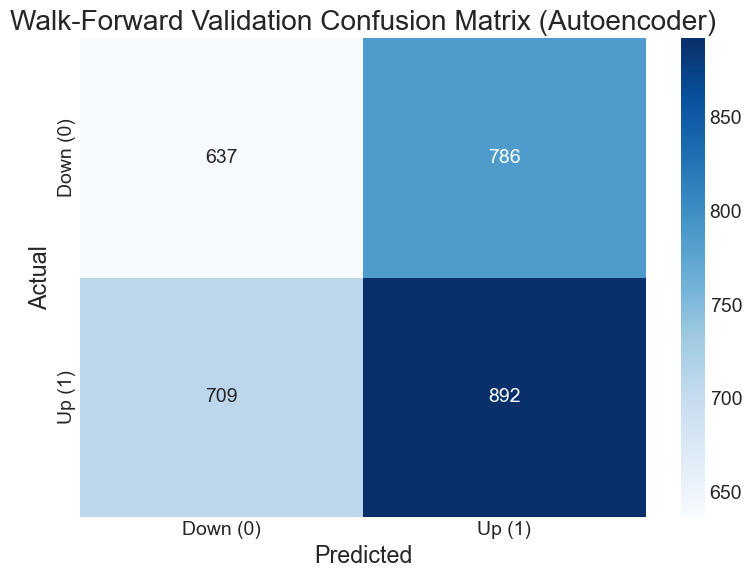

Autoencoder walk-forward predictions saved to 'data/walkforward_predictions_ae.csv'
Creating walk-forward XGBoost model (prevents data leakage)...
Loading final modeling data...
Loaded data with shape (3828, 32)
Filtering data to before current date: 2025-03-24
Performing walk-forward validation with 48 folds

Fold 1/48
Train: 2010-01-04 00:00:00 to 2013-01-03 00:00:00 (756 samples)
Test: 2013-01-04 00:00:00 to 2013-04-05 00:00:00 (63 samples)
Created sample weights with range: 0.9873 to 1.0749
Training XGBoost model for fold 1...

Fold 2/48
Train: 2010-04-06 00:00:00 to 2013-04-05 00:00:00 (756 samples)
Test: 2013-04-08 00:00:00 to 2013-07-05 00:00:00 (63 samples)
Created sample weights with range: 0.9871 to 1.1090
Training XGBoost model for fold 2...

Fold 3/48
Train: 2010-07-06 00:00:00 to 2013-07-05 00:00:00 (756 samples)
Test: 2013-07-08 00:00:00 to 2013-10-03 00:00:00 (63 samples)
Created sample weights with range: 0.9874 to 1.1094
Training XGBoost model for fold 3...

Fold 4/48


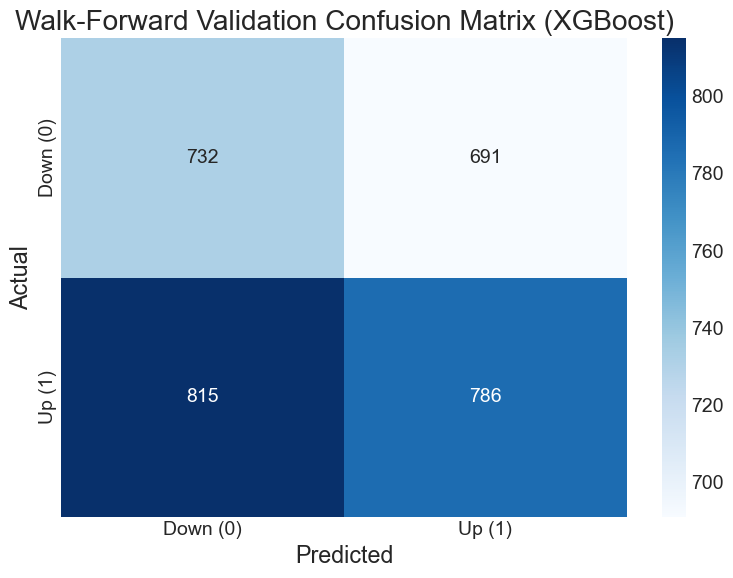

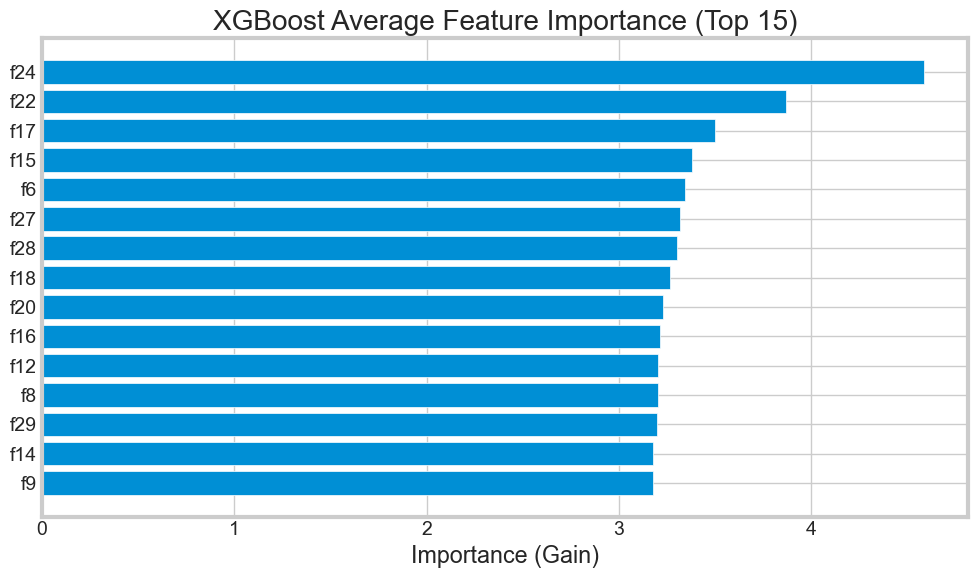

XGBoost walk-forward predictions saved to 'data/walkforward_predictions_xgb.csv'

Creating ensemble model with NO DATA LEAKAGE...
Created ensemble dataframe with shape (3024, 3)
Using ensemble weights: 0.5 for Autoencoder, 0.5 for XGBoost

Ensemble Model Metrics:
Accuracy: 0.5060
Precision: 0.5367
Recall: 0.4884
F1 Score: 0.5114


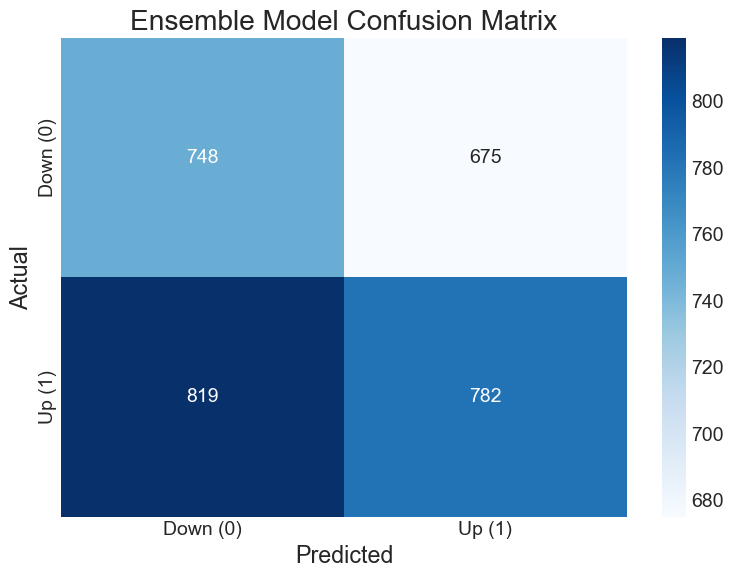

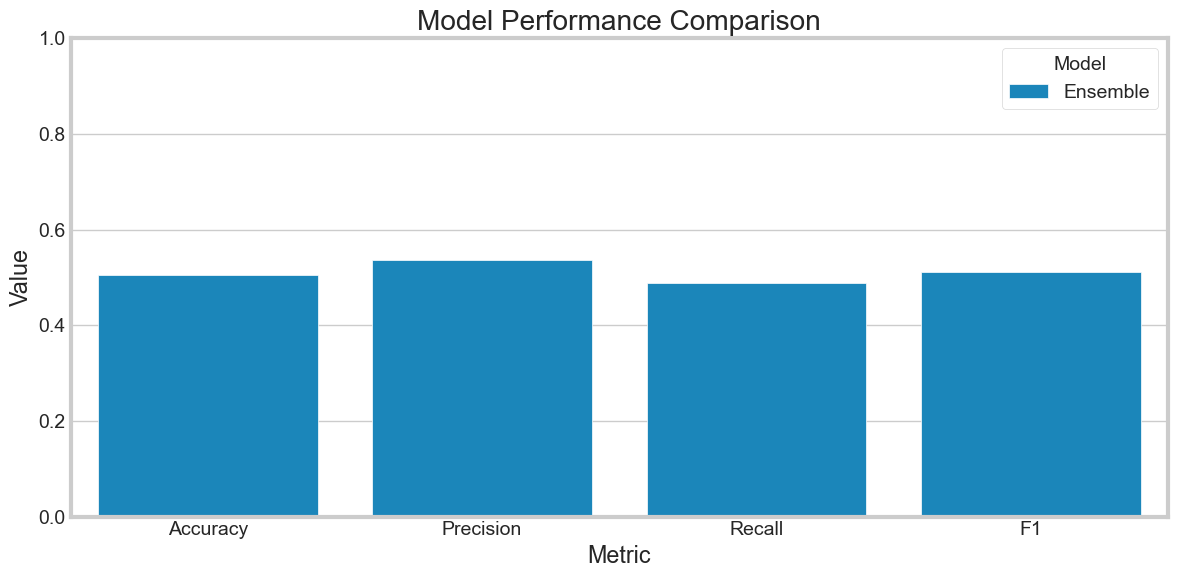

Ensemble predictions saved to 'data/ensemble_predictions_fixed.csv'
Complete pipeline finished successfully


In [63]:
# Cell 10: Complete Weighted Training and Model Ensemble (FIXED - NO DATA LEAKAGE)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import os
import warnings
from datetime import datetime

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
tf.keras.utils.set_random_seed(42)  # For reproducibility

def create_weighted_autoencoder_walkforward(df=None, 
                                           bottleneck_dim=8, 
                                           epochs=20, 
                                           batch_size=64,
                                           train_window=756,  # ~3 years of trading days
                                           test_window=63,    # ~3 months of trading days
                                           noise_std=0.01,
                                           save_model=True):
    """
    Create and train a supervised autoencoder using walk-forward validation
    to prevent data leakage
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with features and target
    bottleneck_dim : int
        Dimension of the bottleneck layer
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    train_window : int
        Number of days in training window
    test_window : int
        Number of days in testing window
    noise_std : float
        Standard deviation of Gaussian noise added to input
    save_model : bool
        Whether to save the trained model
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with predictions from walk-forward validation
    """
    print("Creating walk-forward autoencoder model (prevents data leakage)...")
    
    # Load data if not provided
    if df is None:
        try:
            print("Loading final modeling data...")
            df = pd.read_csv("data/final_modeling_data.csv", index_col=0, parse_dates=True)
            print(f"Loaded data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading final modeling data: {e}")
            return None
    
    # Make a copy to avoid modifying the original
    model_df = df.copy()
    
    # Filter to current date to prevent future data leakage
    current_date = datetime.now().strftime('%Y-%m-%d')
    print(f"Filtering data to before current date: {current_date}")
    model_df = model_df[model_df.index <= current_date]
    
    # Separate features and target
    if 'Target' in model_df.columns:
        target_col = 'Target'
    else:
        print("Target column not found, cannot build model.")
        return None
    
    # Select numeric columns only
    numeric_cols = model_df.select_dtypes(include=['number']).columns.tolist()
    
    # Remove target and group from feature columns
    feature_cols = [col for col in numeric_cols if col != target_col and col != 'group']
    
    # Add proper lag to macroeconomic indicators to prevent look-ahead bias
    macro_indicators = ['DGS10', 'CPI', 'GDP', 'UNRATE']
    for col in macro_indicators:
        if col in model_df.columns:
            if col == 'GDP':
                # GDP has ~3 month publication lag
                model_df[f'{col}_lagged'] = model_df[col].shift(63)
                feature_cols.remove(col)
                feature_cols.append(f'{col}_lagged')
            else:
                # Other indicators have ~1 month lag
                model_df[f'{col}_lagged'] = model_df[col].shift(21)
                feature_cols.remove(col)
                feature_cols.append(f'{col}_lagged')
    
    # Initialize container for predictions
    all_predictions = []
    all_y_test = []
    all_test_dates = []
    
    # Calculate number of walk-forward steps
    total_samples = len(model_df)
    min_required = train_window + test_window
    
    if total_samples < min_required:
        print(f"Not enough data for walk-forward validation. Need at least {min_required} samples.")
        return None
    
    # Determine the start points for each fold
    start_indices = list(range(0, total_samples - min_required + 1, test_window))
    if not start_indices:
        start_indices = [0]  # At least one fold
    
    print(f"Performing walk-forward validation with {len(start_indices)} folds")
    
    # Loop through each fold
    for fold, start_idx in enumerate(start_indices):
        print(f"\nFold {fold+1}/{len(start_indices)}")
        
        # Define train and test indices
        train_end = start_idx + train_window
        test_end = min(train_end + test_window, total_samples)
        
        # Get train/test data for this fold
        train_data = model_df.iloc[start_idx:train_end].copy()
        test_data = model_df.iloc[train_end:test_end].copy()
        
        if len(test_data) == 0:
            print("No test data for this fold. Skipping.")
            continue
        
        print(f"Train: {train_data.index[0]} to {train_data.index[-1]} ({len(train_data)} samples)")
        print(f"Test: {test_data.index[0]} to {test_data.index[-1]} ({len(test_data)} samples)")
        
        # Extract features and target
        X_train = train_data[feature_cols].values
        y_train = train_data[target_col].values
        X_test = test_data[feature_cols].values
        y_test = test_data[target_col].values
        
        # Handle infinities and large values
        X_train = np.nan_to_num(X_train, nan=0, posinf=1e10, neginf=-1e10)
        X_test = np.nan_to_num(X_test, nan=0, posinf=1e10, neginf=-1e10)
        
        # Scale features using ONLY the training data
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Calculate return data for weighting if available
        if 'Return_1d' in train_data.columns:
            returns = train_data['Return_1d'].values
            returns = np.nan_to_num(returns, nan=0)
            sample_weights = np.abs(returns) + 1.0  # Adding 1.0 to avoid zero weights
            sample_weights = sample_weights * (len(sample_weights) / np.sum(sample_weights))
            print(f"Created sample weights with range: {np.min(sample_weights):.4f} to {np.max(sample_weights):.4f}")
        else:
            sample_weights = np.ones(len(y_train))
            print("Using equal sample weights (return data not available)")
        
        # Build model for this fold
        print(f"Building model for fold {fold+1}...")
        
        try:
            # Input layer
            input_layer = Input(shape=(X_train_scaled.shape[1],))
            
            # Add noise for robustness
            noisy_input = GaussianNoise(noise_std)(input_layer)
            
            # Encoder layers
            encoder = Dense(64, activation='swish')(noisy_input)
            encoder = Dropout(0.2)(encoder)
            encoder = Dense(32, activation='swish')(encoder)
            encoder = Dropout(0.2)(encoder)
            
            # Bottleneck layer
            bottleneck = Dense(bottleneck_dim, activation='swish', name='bottleneck')(encoder)
            
            # Classification head
            classifier = Dense(16, activation='swish')(bottleneck)
            classifier = Dropout(0.2)(classifier)
            classifier = Dense(8, activation='swish')(classifier)
            
            # Output layer
            output = Dense(1, activation='sigmoid')(classifier)
            
            # Create and compile model
            model = Model(inputs=input_layer, outputs=output)
            model.compile(
                optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            # Set up early stopping
            early_stopping = EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True,
                mode='max'
            )
            
            # Train model with sample weights
            history = model.fit(
                X_train_scaled, 
                y_train,
                epochs=epochs,
                batch_size=batch_size,
                validation_split=0.2,  # Use part of train set for validation
                sample_weight=sample_weights,
                callbacks=[early_stopping],
                verbose=0
            )
            
            # Get predictions for test set
            y_pred = model.predict(X_test_scaled)
            
            # Store results from this fold
            all_predictions.extend(y_pred.flatten())
            all_y_test.extend(y_test)
            all_test_dates.extend(test_data.index)
            
            # Save the final fold model if requested
            if save_model and fold == len(start_indices) - 1:
                os.makedirs('models', exist_ok=True)
                model.save(f'models/autoencoder_fold_{fold}.keras')
                print(f"Saved final fold model to 'models/autoencoder_fold_{fold}.keras'")
            
        except Exception as e:
            print(f"Error training model for fold {fold+1}: {e}")
            continue
    
    # Create DataFrame with predictions
    results_df = pd.DataFrame({
        'Date': all_test_dates,
        'Actual': all_y_test,
        'Prediction_AE': all_predictions
    })
    results_df['Pred_Binary_AE'] = (results_df['Prediction_AE'] > 0.5).astype(int)
    results_df.set_index('Date', inplace=True)
    
    # Calculate metrics
    accuracy = accuracy_score(results_df['Actual'], results_df['Pred_Binary_AE'])
    precision = precision_score(results_df['Actual'], results_df['Pred_Binary_AE'])
    recall = recall_score(results_df['Actual'], results_df['Pred_Binary_AE'])
    f1 = f1_score(results_df['Actual'], results_df['Pred_Binary_AE'])
    
    print("\nWalk-Forward Validation Metrics (Autoencoder):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(results_df['Actual'], results_df['Pred_Binary_AE'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    plt.title('Walk-Forward Validation Confusion Matrix (Autoencoder)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # Save results
    results_df.to_csv("data/walkforward_predictions_ae.csv")
    print("Autoencoder walk-forward predictions saved to 'data/walkforward_predictions_ae.csv'")
    
    return results_df

def create_xgboost_walkforward(df=None, 
                             train_window=756,  # ~3 years of trading days
                             test_window=63,    # ~3 months of trading days
                             save_model=True):
    """
    Create and train an XGBoost model using walk-forward validation
    to prevent data leakage
    
    Parameters:
    -----------
    df : pandas.DataFrame, optional
        DataFrame with features and target
    train_window : int
        Number of days in training window
    test_window : int
        Number of days in testing window
    save_model : bool
        Whether to save the trained model
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with predictions from walk-forward validation
    """
    print("Creating walk-forward XGBoost model (prevents data leakage)...")
    
    # Load data if not provided
    if df is None:
        try:
            print("Loading final modeling data...")
            df = pd.read_csv("data/final_modeling_data.csv", index_col=0, parse_dates=True)
            print(f"Loaded data with shape {df.shape}")
        except Exception as e:
            print(f"Error loading final modeling data: {e}")
            return None
    
    # Make a copy to avoid modifying the original
    model_df = df.copy()
    
    # Filter to current date to prevent future data leakage
    current_date = datetime.now().strftime('%Y-%m-%d')
    print(f"Filtering data to before current date: {current_date}")
    model_df = model_df[model_df.index <= current_date]
    
    # Separate features and target
    if 'Target' in model_df.columns:
        target_col = 'Target'
    else:
        print("Target column not found, cannot build model.")
        return None
    
    # Select numeric columns only
    numeric_cols = model_df.select_dtypes(include=['number']).columns.tolist()
    
    # Remove target and group from feature columns
    feature_cols = [col for col in numeric_cols if col != target_col and col != 'group']
    
    # Add proper lag to macroeconomic indicators to prevent look-ahead bias
    macro_indicators = ['DGS10', 'CPI', 'GDP', 'UNRATE']
    for col in macro_indicators:
        if col in model_df.columns:
            if col == 'GDP':
                # GDP has ~3 month publication lag
                model_df[f'{col}_lagged'] = model_df[col].shift(63)
                feature_cols.remove(col)
                feature_cols.append(f'{col}_lagged')
            else:
                # Other indicators have ~1 month lag
                model_df[f'{col}_lagged'] = model_df[col].shift(21)
                feature_cols.remove(col)
                feature_cols.append(f'{col}_lagged')
    
    # Initialize container for predictions
    all_predictions = []
    all_y_test = []
    all_test_dates = []
    all_importances = []
    
    # Calculate number of walk-forward steps
    total_samples = len(model_df)
    min_required = train_window + test_window
    
    if total_samples < min_required:
        print(f"Not enough data for walk-forward validation. Need at least {min_required} samples.")
        return None
    
    # Determine the start points for each fold
    start_indices = list(range(0, total_samples - min_required + 1, test_window))
    if not start_indices:
        start_indices = [0]  # At least one fold
    
    print(f"Performing walk-forward validation with {len(start_indices)} folds")
    
    # Loop through each fold
    for fold, start_idx in enumerate(start_indices):
        print(f"\nFold {fold+1}/{len(start_indices)}")
        
        # Define train and test indices
        train_end = start_idx + train_window
        test_end = min(train_end + test_window, total_samples)
        
        # Get train/test data for this fold
        train_data = model_df.iloc[start_idx:train_end].copy()
        test_data = model_df.iloc[train_end:test_end].copy()
        
        if len(test_data) == 0:
            print("No test data for this fold. Skipping.")
            continue
        
        print(f"Train: {train_data.index[0]} to {train_data.index[-1]} ({len(train_data)} samples)")
        print(f"Test: {test_data.index[0]} to {test_data.index[-1]} ({len(test_data)} samples)")
        
        # Extract features and target
        X_train = train_data[feature_cols].values
        y_train = train_data[target_col].values
        X_test = test_data[feature_cols].values
        y_test = test_data[target_col].values
        
        # Handle infinities and large values
        X_train = np.nan_to_num(X_train, nan=0, posinf=1e10, neginf=-1e10)
        X_test = np.nan_to_num(X_test, nan=0, posinf=1e10, neginf=-1e10)
        
        # Calculate return data for weighting if available
        if 'Return_1d' in train_data.columns:
            returns = train_data['Return_1d'].values
            returns = np.nan_to_num(returns, nan=0)
            sample_weights = np.abs(returns) + 1.0  # Adding 1.0 to avoid zero weights
            sample_weights = sample_weights * (len(sample_weights) / np.sum(sample_weights))
            print(f"Created sample weights with range: {np.min(sample_weights):.4f} to {np.max(sample_weights):.4f}")
        else:
            sample_weights = np.ones(len(y_train))
            print("Using equal sample weights (return data not available)")
        
        # Train XGBoost model
        print(f"Training XGBoost model for fold {fold+1}...")
        
        try:
            # Set XGBoost parameters
            params = {
                'objective': 'binary:logistic',
                'eval_metric': ['logloss', 'error'],
                'eta': 0.05,
                'max_depth': 6,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'min_child_weight': 1,
                'seed': 42
            }
            
            # Create DMatrix for training and evaluation
            dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
            dtest = xgb.DMatrix(X_test, label=y_test)
            
            # Train model with early stopping
            num_rounds = 500
            evals = [(dtrain, 'train'), (dtest, 'eval')]
            
            model = xgb.train(
                params,
                dtrain,
                num_rounds,
                evals=evals,
                early_stopping_rounds=50,
                verbose_eval=False
            )
            
            # Get predictions for test set
            y_pred = model.predict(dtest)
            
            # Store feature importance for this fold
            importance = model.get_score(importance_type='gain')
            importance_df = pd.DataFrame({
                'Feature': list(importance.keys()),
                'Importance': list(importance.values()),
                'Fold': fold + 1
            })
            all_importances.append(importance_df)
            
            # Store results from this fold
            all_predictions.extend(y_pred)
            all_y_test.extend(y_test)
            all_test_dates.extend(test_data.index)
            
            # Save the final fold model if requested
            if save_model and fold == len(start_indices) - 1:
                os.makedirs('models', exist_ok=True)
                model.save_model(f'models/xgboost_fold_{fold}.json')
                print(f"Saved final fold model to 'models/xgboost_fold_{fold}.json'")
            
        except Exception as e:
            print(f"Error training XGBoost model for fold {fold+1}: {e}")
            continue
    
    # Create DataFrame with predictions
    results_df = pd.DataFrame({
        'Date': all_test_dates,
        'Actual': all_y_test,
        'Prediction_XGB': all_predictions
    })
    results_df['Pred_Binary_XGB'] = (results_df['Prediction_XGB'] > 0.5).astype(int)
    results_df.set_index('Date', inplace=True)
    
    # Calculate metrics
    accuracy = accuracy_score(results_df['Actual'], results_df['Pred_Binary_XGB'])
    precision = precision_score(results_df['Actual'], results_df['Pred_Binary_XGB'])
    recall = recall_score(results_df['Actual'], results_df['Pred_Binary_XGB'])
    f1 = f1_score(results_df['Actual'], results_df['Pred_Binary_XGB'])
    
    print("\nWalk-Forward Validation Metrics (XGBoost):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(results_df['Actual'], results_df['Pred_Binary_XGB'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    plt.title('Walk-Forward Validation Confusion Matrix (XGBoost)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # Plot average feature importance if we have data
    if all_importances:
        # Combine all fold importances
        all_importance_df = pd.concat(all_importances)
        
        # Calculate average importance by feature
        avg_importance = all_importance_df.groupby('Feature')['Importance'].mean().reset_index()
        avg_importance = avg_importance.sort_values('Importance', ascending=False).head(15)
        
        plt.figure(figsize=(10, 6))
        plt.barh(avg_importance['Feature'], avg_importance['Importance'])
        plt.title('XGBoost Average Feature Importance (Top 15)')
        plt.xlabel('Importance (Gain)')
        plt.gca().invert_yaxis()  # Highest importance at the top
        plt.tight_layout()
        plt.show()
    
    # Save results
    results_df.to_csv("data/walkforward_predictions_xgb.csv")
    print("XGBoost walk-forward predictions saved to 'data/walkforward_predictions_xgb.csv'")
    
    return results_df

def create_ensemble_model(ae_df=None, xgb_df=None, ensemble_weight=0.5):
    """
    Create ensemble predictions by combining autoencoder and XGBoost model predictions
    
    Parameters:
    -----------
    ae_df : pandas.DataFrame, optional
        DataFrame with autoencoder predictions
    xgb_df : pandas.DataFrame, optional
        DataFrame with XGBoost predictions
    ensemble_weight : float
        Weight for autoencoder predictions (1-weight for XGBoost)
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with ensemble predictions
    """
    print("\nCreating ensemble model with NO DATA LEAKAGE...")
    
    # Load predictions if not provided
    if ae_df is None:
        try:
            print("Loading autoencoder predictions...")
            ae_df = pd.read_csv("data/walkforward_predictions_ae.csv", index_col=0, parse_dates=True)
            print(f"Loaded autoencoder predictions with shape {ae_df.shape}")
        except Exception as e:
            print(f"Error loading autoencoder predictions: {e}")
            return None
    
    if xgb_df is None:
        try:
            print("Loading XGBoost predictions...")
            xgb_df = pd.read_csv("data/walkforward_predictions_xgb.csv", index_col=0, parse_dates=True)
            print(f"Loaded XGBoost predictions with shape {xgb_df.shape}")
        except Exception as e:
            print(f"Error loading XGBoost predictions: {e}")
            return None
    
    # Check if we have the required columns
    ae_cols = ['Actual', 'Prediction_AE']
    xgb_cols = ['Actual', 'Prediction_XGB']
    
    missing_ae_cols = [col for col in ae_cols if col not in ae_df.columns]
    missing_xgb_cols = [col for col in xgb_cols if col not in xgb_df.columns]
    
    if missing_ae_cols:
        print(f"Missing required columns in autoencoder predictions: {missing_ae_cols}")
        # Try to adapt column names if possible
        if 'Prediction' in ae_df.columns and 'Prediction_AE' in missing_ae_cols:
            ae_df['Prediction_AE'] = ae_df['Prediction']
            missing_ae_cols.remove('Prediction_AE')
        
        if missing_ae_cols:
            print("Cannot create ensemble without required autoencoder predictions.")
            return None
    
    if missing_xgb_cols:
        print(f"Missing required columns in XGBoost predictions: {missing_xgb_cols}")
        # Try to adapt column names if possible
        if 'Prediction' in xgb_df.columns and 'Prediction_XGB' in missing_xgb_cols:
            xgb_df['Prediction_XGB'] = xgb_df['Prediction']
            missing_xgb_cols.remove('Prediction_XGB')
        
        if missing_xgb_cols:
            print("Cannot create ensemble without required XGBoost predictions.")
            return None
    
    # Merge predictions on date index
    ensemble_df = pd.merge(ae_df[['Actual', 'Prediction_AE']], 
                         xgb_df[['Prediction_XGB']], 
                         left_index=True, 
                         right_index=True)
    
    print(f"Created ensemble dataframe with shape {ensemble_df.shape}")
    
    # Calculate ensemble predictions
    print(f"Using ensemble weights: {ensemble_weight} for Autoencoder, {1-ensemble_weight} for XGBoost")
    ensemble_df['Prediction_Ensemble'] = (
        ensemble_weight * ensemble_df['Prediction_AE'] + 
        (1 - ensemble_weight) * ensemble_df['Prediction_XGB']
    )
    
    ensemble_df['Pred_Binary_Ensemble'] = (ensemble_df['Prediction_Ensemble'] > 0.5).astype(int)
    
    # Calculate metrics for ensemble
    accuracy = accuracy_score(ensemble_df['Actual'], ensemble_df['Pred_Binary_Ensemble'])
    precision = precision_score(ensemble_df['Actual'], ensemble_df['Pred_Binary_Ensemble'])
    recall = recall_score(ensemble_df['Actual'], ensemble_df['Pred_Binary_Ensemble'])
    f1 = f1_score(ensemble_df['Actual'], ensemble_df['Pred_Binary_Ensemble'])
    
    print("\nEnsemble Model Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(ensemble_df['Actual'], ensemble_df['Pred_Binary_Ensemble'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    plt.title('Ensemble Model Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # Compare model performances
    model_names = ['Autoencoder', 'XGBoost', 'Ensemble']
    pred_cols = ['Pred_Binary_AE', 'Pred_Binary_XGB', 'Pred_Binary_Ensemble']
    
    metrics = []
    for name, col in zip(model_names, pred_cols):
        if col in ensemble_df.columns:
            acc = accuracy_score(ensemble_df['Actual'], ensemble_df[col])
            prec = precision_score(ensemble_df['Actual'], ensemble_df[col])
            rec = recall_score(ensemble_df['Actual'], ensemble_df[col])
            f1 = f1_score(ensemble_df['Actual'], ensemble_df[col])
            metrics.append([name, acc, prec, rec, f1])
    
    metrics_df = pd.DataFrame(metrics, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
    
    # Plot comparison
    plt.figure(figsize=(12, 6))
    metrics_long = pd.melt(metrics_df, id_vars=['Model'], var_name='Metric', value_name='Value')
    sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_long)
    plt.title('Model Performance Comparison')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    
    # Save ensemble predictions
    ensemble_df.to_csv("data/ensemble_predictions_fixed.csv")
    print("Ensemble predictions saved to 'data/ensemble_predictions_fixed.csv'")
    
    return ensemble_df

# Run the fixed model pipeline
print("Running complete walk-forward validation pipeline with NO DATA LEAKAGE")

# Step 1: Run autoencoder walkforward
ae_results = create_weighted_autoencoder_walkforward()

# Step 2: Run XGBoost walkforward
xgb_results = create_xgboost_walkforward()

# Step 3: Create ensemble model
if ae_results is not None and xgb_results is not None:
    ensemble_results = create_ensemble_model(ae_results, xgb_results, ensemble_weight=0.5)
    print("Complete pipeline finished successfully")
else:
    print("Could not create ensemble due to missing model predictions")


Backtesting trading strategy with NO DATA LEAKAGE...
Filtering data to before current date: 2025-03-24
Loading stock price data for AAPL...

Performance Metrics (NO DATA LEAKAGE):
Period: 2013-01-04 to 2025-01-10 (12.02 years)
Initial Capital: $10000.00
Total Trades: 518.0

Buy & Hold Strategy:
  Final Value: $151519.33
  Total Return: 1415.19%
  Annualized Return: 25.36%
  Maximum Drawdown: -38.52%
  Sharpe Ratio: 0.9084

Model-Based Trading Strategy:
  Final Value: $55754.98
  Total Return: 457.55%
  Annualized Return: 15.36%
  Maximum Drawdown: -40.31%
  Sharpe Ratio: 0.7836
  Win Rate: 29.20%


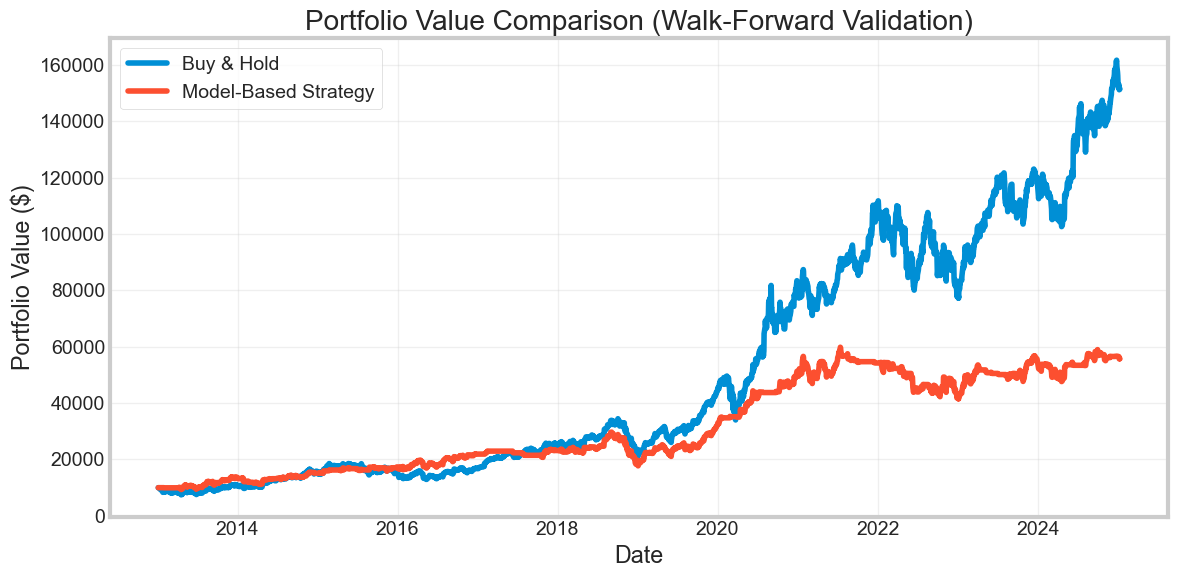

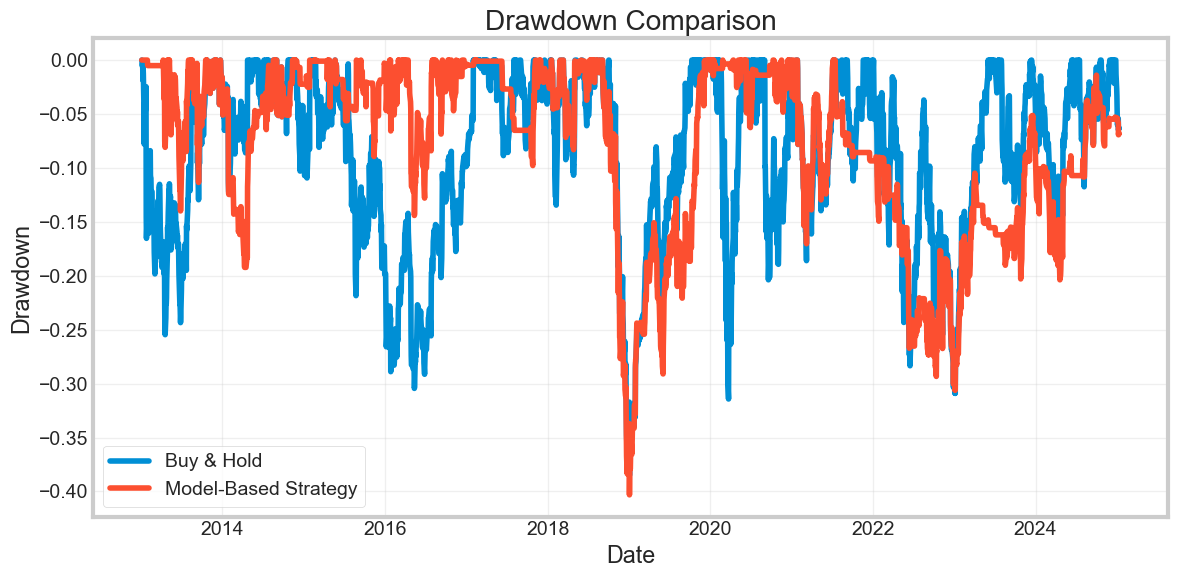

Backtest results saved to 'data/backtest_results_fixed.csv'


In [65]:
# Cell 11: Backtesting Trading Strategy (FIXED - NO DATA LEAKAGE)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import os
import warnings
from datetime import datetime

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def backtest_trading_strategy_fixed(predictions_df=None, ticker='AAPL', initial_capital=10000, transaction_cost=0.001):
    """
    Backtest trading strategy based on walk-forward predictions
    with NO DATA LEAKAGE
    
    Parameters:
    -----------
    predictions_df : pandas.DataFrame
        DataFrame with predictions from walk-forward validation
    ticker : str
        Stock ticker symbol
    initial_capital : float
        Initial capital for backtesting
    transaction_cost : float
        Transaction cost as a fraction of trade value
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with backtesting results
    """
    print("\nBacktesting trading strategy with NO DATA LEAKAGE...")
    
    # Load walk-forward predictions if not provided
    if predictions_df is None:
        try:
            print("Loading walk-forward predictions...")
            predictions_df = pd.read_csv("data/walkforward_predictions.csv", index_col=0, parse_dates=True)
            print(f"Loaded predictions with shape {predictions_df.shape}")
        except Exception as e:
            print(f"Error loading walk-forward predictions: {e}")
            return None
    
    # Filter to current date to prevent future data
    current_date = datetime.now().strftime('%Y-%m-%d')
    print(f"Filtering data to before current date: {current_date}")
    predictions_df = predictions_df[predictions_df.index <= current_date]
    
    # Ensure we have the required columns
    required_cols = ['Actual', 'Prediction', 'Pred_Binary']
    missing_cols = [col for col in required_cols if col not in predictions_df.columns]
    
    if missing_cols:
        print(f"Missing required columns: {missing_cols}")
        if 'Pred_Binary' in missing_cols and 'Prediction' in predictions_df.columns:
            predictions_df['Pred_Binary'] = (predictions_df['Prediction'] > 0.5).astype(int)
            missing_cols.remove('Pred_Binary')
        
        if missing_cols:
            print("Cannot proceed with backtesting.")
            return None
    
    # Get stock price data
    print(f"Loading stock price data for {ticker}...")
    start_date = predictions_df.index.min().strftime('%Y-%m-%d')
    end_date = predictions_df.index.max().strftime('%Y-%m-%d')
    
    try:
        # Load stock price data matching prediction dates
        stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        
        # Join with predictions
        backtest_df = pd.DataFrame(index=predictions_df.index)
        backtest_df['Close'] = stock_data['Close'].reindex(backtest_df.index)
        
        # Forward fill any missing prices
        backtest_df['Close'] = backtest_df['Close'].ffill()
        
        # Add predictions
        backtest_df['Prediction'] = predictions_df['Prediction']
        backtest_df['Pred_Binary'] = predictions_df['Pred_Binary']
        backtest_df['Actual'] = predictions_df['Actual']
        
    except Exception as e:
        print(f"Error loading stock data: {e}")
        print("Attempting to use original data...")
        
        try:
            # Load original data
            df = pd.read_csv("data/final_modeling_data.csv", index_col=0, parse_dates=True)
            if 'Close' in df.columns:
                backtest_df = pd.DataFrame(index=predictions_df.index)
                backtest_df['Close'] = df['Close'].reindex(backtest_df.index)
                backtest_df['Prediction'] = predictions_df['Prediction']
                backtest_df['Pred_Binary'] = predictions_df['Pred_Binary']
                backtest_df['Actual'] = predictions_df['Actual']
            else:
                print("No price data available. Cannot backtest.")
                return None
        except Exception as e2:
            print(f"Error loading original data: {e2}")
            return None
    
    # Make sure we have Close prices
    if 'Close' not in backtest_df.columns or backtest_df['Close'].isna().all():
        print("No price data available. Cannot backtest.")
        return None
    
    # Calculate returns
    backtest_df['Return'] = backtest_df['Close'].pct_change()
    backtest_df.loc[backtest_df.index[0], 'Return'] = 0  # No return for first day
    
    # Calculate strategy returns - Use PREVIOUS day's prediction
    # This prevents look-ahead bias, as we'd only know the prediction at market close
    # and would need to trade at the next day's open
    backtest_df['Position'] = backtest_df['Pred_Binary'].shift(1)
    backtest_df['Position'] = backtest_df['Position'].fillna(0)  # No position for first day
    
    # Strategy returns based on positions
    backtest_df['Strategy_Return'] = backtest_df['Position'] * backtest_df['Return']
    
    # Account for transaction costs
    backtest_df['Position_Change'] = backtest_df['Position'].diff().fillna(0).abs()
    backtest_df['Transaction_Cost'] = backtest_df['Position_Change'] * transaction_cost
    backtest_df['Strategy_Return'] = backtest_df['Strategy_Return'] - backtest_df['Transaction_Cost']
    
    # Cumulative returns
    backtest_df['Cumulative_Return'] = (1 + backtest_df['Return']).cumprod() - 1
    backtest_df['Strategy_Cumulative_Return'] = (1 + backtest_df['Strategy_Return']).cumprod() - 1
    
    # Portfolio value
    backtest_df['Buy_Hold_Value'] = initial_capital * (1 + backtest_df['Cumulative_Return'])
    backtest_df['Strategy_Value'] = initial_capital * (1 + backtest_df['Strategy_Cumulative_Return'])
    
    # Calculate drawdown
    backtest_df['Buy_Hold_Peak'] = backtest_df['Buy_Hold_Value'].cummax()
    backtest_df['Strategy_Peak'] = backtest_df['Strategy_Value'].cummax()
    
    backtest_df['Buy_Hold_Drawdown'] = (backtest_df['Buy_Hold_Value'] / backtest_df['Buy_Hold_Peak']) - 1
    backtest_df['Strategy_Drawdown'] = (backtest_df['Strategy_Value'] / backtest_df['Strategy_Peak']) - 1
    
    # Performance metrics
    days = (backtest_df.index[-1] - backtest_df.index[0]).days
    years = max(days / 365, 0.01)  # Avoid division by zero
    
    # Final returns
    final_buy_hold_return = backtest_df['Cumulative_Return'].iloc[-1]
    final_strategy_return = backtest_df['Strategy_Cumulative_Return'].iloc[-1]
    
    # Maximum drawdowns
    max_buy_hold_drawdown = backtest_df['Buy_Hold_Drawdown'].min()
    max_strategy_drawdown = backtest_df['Strategy_Drawdown'].min()
    
    # Annual returns
    buy_hold_annual_return = (1 + final_buy_hold_return) ** (1 / years) - 1
    strategy_annual_return = (1 + final_strategy_return) ** (1 / years) - 1
    
    # Volatility (annualized)
    buy_hold_annual_vol = backtest_df['Return'].std() * np.sqrt(252)
    strategy_annual_vol = backtest_df['Strategy_Return'].std() * np.sqrt(252)
    
    # Sharpe ratio
    buy_hold_sharpe = buy_hold_annual_return / buy_hold_annual_vol if buy_hold_annual_vol != 0 else 0
    strategy_sharpe = strategy_annual_return / strategy_annual_vol if strategy_annual_vol != 0 else 0
    
    # Win rate
    total_trades = backtest_df['Position_Change'].sum()
    profitable_days = (backtest_df['Strategy_Return'] > 0).sum()
    win_rate = profitable_days / len(backtest_df) if len(backtest_df) > 0 else 0
    
    # Print performance metrics
    print("\nPerformance Metrics (NO DATA LEAKAGE):")
    print(f"Period: {backtest_df.index[0].date()} to {backtest_df.index[-1].date()} ({years:.2f} years)")
    print(f"Initial Capital: ${initial_capital:.2f}")
    print(f"Total Trades: {total_trades}")
    
    print("\nBuy & Hold Strategy:")
    print(f"  Final Value: ${backtest_df['Buy_Hold_Value'].iloc[-1]:.2f}")
    print(f"  Total Return: {final_buy_hold_return:.2%}")
    print(f"  Annualized Return: {buy_hold_annual_return:.2%}")
    print(f"  Maximum Drawdown: {max_buy_hold_drawdown:.2%}")
    print(f"  Sharpe Ratio: {buy_hold_sharpe:.4f}")
    
    print("\nModel-Based Trading Strategy:")
    print(f"  Final Value: ${backtest_df['Strategy_Value'].iloc[-1]:.2f}")
    print(f"  Total Return: {final_strategy_return:.2%}")
    print(f"  Annualized Return: {strategy_annual_return:.2%}")
    print(f"  Maximum Drawdown: {max_strategy_drawdown:.2%}")
    print(f"  Sharpe Ratio: {strategy_sharpe:.4f}")
    print(f"  Win Rate: {win_rate:.2%}")
    
    # Plot portfolio value comparison
    plt.figure(figsize=(12, 6))
    plt.plot(backtest_df.index, backtest_df['Buy_Hold_Value'], label='Buy & Hold')
    plt.plot(backtest_df.index, backtest_df['Strategy_Value'], label='Model-Based Strategy')
    plt.title('Portfolio Value Comparison (Walk-Forward Validation)')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot drawdown
    plt.figure(figsize=(12, 6))
    plt.plot(backtest_df.index, backtest_df['Buy_Hold_Drawdown'], label='Buy & Hold')
    plt.plot(backtest_df.index, backtest_df['Strategy_Drawdown'], label='Model-Based Strategy')
    plt.title('Drawdown Comparison')
    plt.xlabel('Date')
    plt.ylabel('Drawdown')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Save backtest results
    backtest_df.to_csv("data/backtest_results_fixed.csv")
    print("Backtest results saved to 'data/backtest_results_fixed.csv'")
    
    return backtest_df

# Execute fixed backtesting on results from walk-forward validation
try:
    # Try to load walk-forward predictions from the output of our fixed Cell 10
    walkforward_predictions = pd.read_csv("data/walkforward_predictions.csv", 
                                         index_col=0, parse_dates=True)
    fixed_backtest = backtest_trading_strategy_fixed(walkforward_predictions)
except Exception as e:
    print(f"Error loading walk-forward predictions: {e}")
    print("Please run the fixed Cell 10 first to generate walk-forward predictions.")